<a href="https://colab.research.google.com/github/Thaer-F-Ali/Logistitc_Regression_Implimitation/blob/main/logistic_regression_implimintaion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  1st Logistic Regression Model

Logistic Regression is a supervised machine learning algorithm used for binary classification tasks. Below is a Python implementation using the scikit-learn library.

Steps to Implement Logistic Regression

1. Import Required Libraries

In [1]:
# 1. Laoding libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import accuracy_score,roc_curve, classification_report, confusion_matrix, mean_squared_error, r2_score,  roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from matplotlib.patches import ConnectionPatch
from scipy.stats import norm
import statistics
import plotly.graph_objects as go
import plotly.express as px
from plotly.offline import init_notebook_mode
init_notebook_mode(connected=True)


2. Load and Prepare the Dataset

For demonstration, we'll use the diabetes dataset from sklearn.

In [ ]:
# 2. Loading dataset and prepare dataset
from sklearn.datasets import load_diabetes
# Load dataset
data = load_diabetes()
X, y = data.data, data.target
# Convert target to binary (1 for diabetes, 0 for no diabetes)
y_binary = (y > np.median(y)).astype(int)

In [ ]:
# 2. This step is same as the one above
#Converting database to dataframe .... this is a nother way for representing data
# data.data contains the feature values, data.feature_names contains the column labels
df = pd.DataFrame(data.data, columns=data.feature_names)

X1 = df.copy()

# data.target contains the target values, we need to give it a column name for the DataFrame
y1 = pd.DataFrame(data.target, columns=['target'])

y1_binary = (y1 > np.median(y1)).astype(int)
#print(X1)
#print(y1_binary)

3. Split the Dataset

Split the data into training and testing sets.

In [ ]:
# 3. Spliting the data using the dataframe dataset
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1_binary, test_size=0.3, random_state=42)

4. Feature Scaling

Standardize features to improve model performance.

In [ ]:
# 4. Scalling data
scaler = StandardScaler()
X1_train = scaler.fit_transform(X1_train)
X1_test = scaler.transform(X1_test)

5. Train the Logistic Regression Model

Fit the logistic regression model on the training data.

In [ ]:
# 5. Create logistic model and train it
model1 = LogisticRegression(class_weight='balanced', max_iter=1000, solver='liblinear')
model1.fit(X1_train, y1_train)

LogisticRegression(class_weight='balanced', max_iter=1000, solver='liblinear')

6. Evaluate the Model

Evaluate the model's performance using accuracy and other metrics.

In [ ]:
#6  Predict on test data
y1_pred = model1.predict(X1_test)

# Accuracy score
accuracy = accuracy_score(y1_test, y1_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

# Confusion Matrix and Classification Report
print("Confusion Matrix:\n", confusion_matrix(y1_test, y1_pred))
print("\nClassification Report:\n", classification_report(y1_test, y1_pred))

Accuracy: 77.44%
Confusion Matrix:
 [[56 16]
 [14 47]]

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.78      0.79        72
           1       0.75      0.77      0.76        61

    accuracy                           0.77       133
   macro avg       0.77      0.77      0.77       133
weighted avg       0.78      0.77      0.77       133



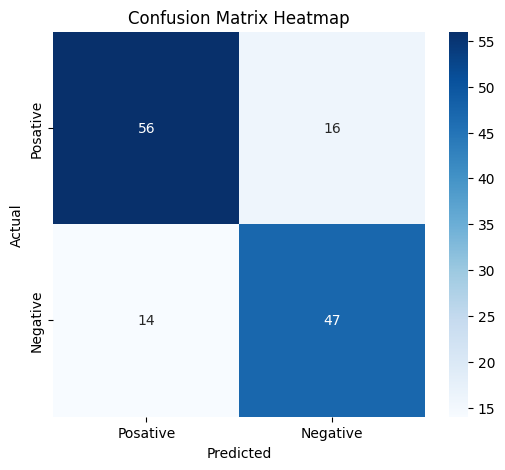

In [ ]:
# 7. Ploting the Confusion matrix in a heatmap graph
cm = confusion_matrix(y1_test, y1_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Posative', 'Negative'], yticklabels=['Posative', 'Negative'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap')
plt.show()

ROC-AUC Score: 0.7741


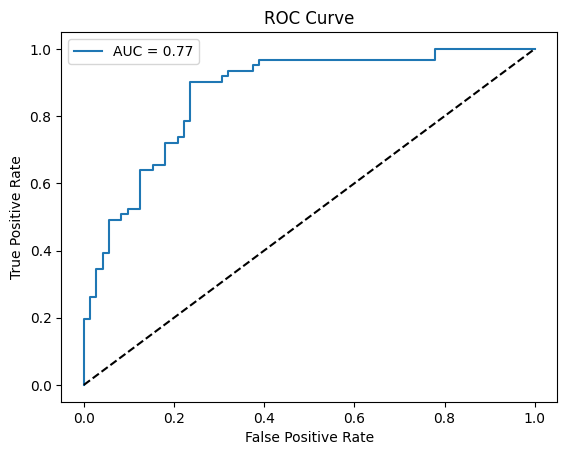

In [ ]:
# 8. Ploting the Area Under Cover matrex
y1_pred = model1.predict(X1_test)
y1_prob = model1.predict_proba(X1_test)[:, 1]
# ROC-AUC Score
roc_auc1 = roc_auc_score(y1_test, y1_pred)
print(f"ROC-AUC Score: {roc_auc1:.4f}")

# ROC Curve
fpr1, tpr1, thresholds1 = roc_curve(y1_test, y1_prob, pos_label=None, sample_weight=None, drop_intermediate=True)
plt.plot(fpr1, tpr1, label=f"AUC = {roc_auc1:.2f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()




In [ ]:
# 9. Printing selected resuls (this source for comparing the results with program in the Applied Machine Learning with Python book, page 62)

print('Prediction:', y1_pred[1], y1_pred[6], y1_pred[25])
print('Raw Model Output X_test: ',
      (model1.coef_@ X1_test[1]+model1.intercept_),
      (model1.coef_@X1_test[6]+model1.intercept_),
      (model1.coef_@X1_test[25] + model1.intercept_))


Prediction: 1 1 1
Raw Model Output X_test:  [1.4005299] [2.38762583] [0.4592164]


# 2nd Logistic Regersion Model

This model is from the Applied Machine Learning with Python book-page 62

In [ ]:
# 1. Preparing data
#X2 = data.data
#y2= data.target
#print(data.feature_names)
#print(data.DESCR)

data2 = load_diabetes()
X2, y2 = data2.data, data2.target
# Convert target to binary (1 for diabetes, 0 for no diabetes)
y2_binary = (y2 > np.median(y2)).astype(int)

In [ ]:
# 2. Spliting data
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2_binary, test_size= 0.3, random_state= 42)

In [ ]:
# 3. Craeting the model and train it
model2 = LogisticRegression(class_weight='balanced', max_iter=1000, solver='liblinear')
model2.fit(X2_train, y2_train)


LogisticRegression(class_weight='balanced', max_iter=1000, solver='liblinear')

In [ ]:
# 4.Testting and evaluating the model
y2_pred = model2.predict(X2_test)
accuracy = accuracy_score(y2_test, y2_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

# Confusion Matrix and Classification Report
print("Confusion Matrix:\n", confusion_matrix(y2_test, y2_pred))
print("\nClassification Report:\n", classification_report(y2_test, y2_pred))

Accuracy: 82.71%
Confusion Matrix:
 [[60 12]
 [11 50]]

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.83      0.84        72
           1       0.81      0.82      0.81        61

    accuracy                           0.83       133
   macro avg       0.83      0.83      0.83       133
weighted avg       0.83      0.83      0.83       133



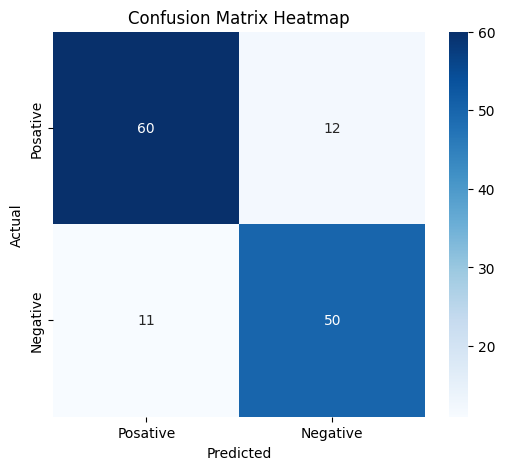

In [ ]:
# 5. Plorting the confusion matrix for the model
cm = confusion_matrix(y2_test, y2_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Posative', 'Negative'], yticklabels=['Posative', 'Negative'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap')
plt.show()

ROC-AUC Score: 0.8265


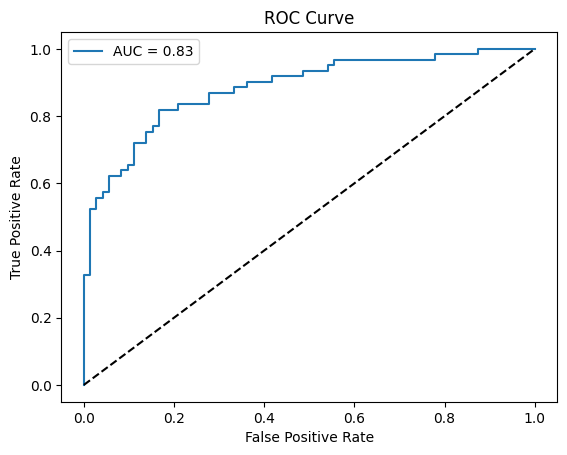

In [ ]:
# 6. Ploting the Area Under Cover matrex
y2_pred = model2.predict(X2_test)
y2_prob = model2.predict_proba(X2_test)[:, 1]
# ROC-AUC Score
roc_auc = roc_auc_score(y2_test, y2_pred)
print(f"ROC-AUC Score: {roc_auc:.4f}")

# ROC Curve
fpr, tpr, thresholds = roc_curve(y2_test, y2_prob)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

### Comparing Coefficients of Scaled vs. Unscaled Models

In [ ]:
# 7. Printing the coefficients
print('Prediction:', model2.predict(X2_test)[1], model2.predict(X2_test)[6], model2.predict(X2_test)[25])
print('Raw Model Output X_test: ',
      (model2.coef_@ X2_test[1] + model2.intercept_),
      (model2.coef_@ X2_test[6] + model2.intercept_),
      (model2.coef_@ X2_test[25]+ model2.intercept_))


Prediction: 1 1 1
Raw Model Output X_test:  [0.06872581] [0.56842377] [0.1036519]


In [ ]:
# 8. Comparing cofficients of the scaled (Model1) and unscaled (Model2) models
print("Scaled Model (model1):")
print("  Coefficients:", model1.coef_)
print("  Intercept:", model1.intercept_)

print("\nUnscaled Model (model2):")
print("  Coefficients:", model2.coef_)
print("  Intercept:", model2.intercept_)

Scaled Model (model1):
  Coefficients: [[ 0.10716414 -0.5827291   0.67281842  0.61747534 -0.31740152 -0.09261729
  -0.52312851  0.10103143  0.6171705  -0.0491861 ]]
  Intercept: [0.0743892]

Unscaled Model (model2):
  Coefficients: [[ 0.57438882 -0.64998805  2.35878959  1.85392157  0.18783239  0.05811034
  -1.59184274  1.32349664  1.94607996  1.15463067]]
  Intercept: [-0.0129211]


# 3rd Logistic Regression with data analysis in real example

*   This example is from the Kegale platform with name Diabetes Analysis
*   The dataset is a collection from  African-American patients were included


---





In [2]:
# 1. Importing dataset
# Please upload 'diabetes.csv' to your Colab session, or provide the correct path.
diab_data3= pd.read_csv('/content/sample_data/germany_diabetes.csv')
diab_data3.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,5,121,72,23,112,26.2,0.245,30,0
1,3,99,54,19,86,25.6,0.154,24,0
2,4,125,70,18,122,28.9,1.144,45,1
3,2,96,68,13,49,21.1,0.647,26,0
4,3,102,44,20,94,30.8,0.400,26,1


In [3]:
# 1.1 Rename the boood_glucose_level to glyhd
diab_data3 = diab_data3.rename(columns={'Outcome': 'glyhb'})

diab_data3.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,glyhb
0,5,121,72,23,112,26.2,0.245,30,0
1,3,99,54,19,86,25.6,0.154,24,0
2,4,125,70,18,122,28.9,1.144,45,1
3,2,96,68,13,49,21.1,0.647,26,0
4,3,102,44,20,94,30.8,0.400,26,1
5,2,100,66,20,90,32.9,0.867,28,0
6,8,100,74,40,215,39.4,0.661,43,0
7,5,109,62,41,129,35.8,0.514,25,0
8,0,95,85,25,36,37.4,0.247,24,0
9,0,97,64,36,100,36.8,0.600,25,1


In [4]:
# 1.2 Exploring data in the dataset
diab_data3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1035 entries, 0 to 1034
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               1035 non-null   int64  
 1   Glucose                   1035 non-null   int64  
 2   BloodPressure             1035 non-null   int64  
 3   SkinThickness             1035 non-null   int64  
 4   Insulin                   1035 non-null   int64  
 5   BMI                       1035 non-null   float64
 6   DiabetesPedigreeFunction  1035 non-null   float64
 7   Age                       1035 non-null   int64  
 8   glyhb                     1035 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 72.9 KB


### Building LR model

Descriptive statistics for 'diabetes' column:


,DiabetesPedigreeFunction
count,1035.000000
mean,0.522839
std,0.332292
min,0.085000
25%,0.282000
50%,0.452000
75%,0.684500
max,2.420000


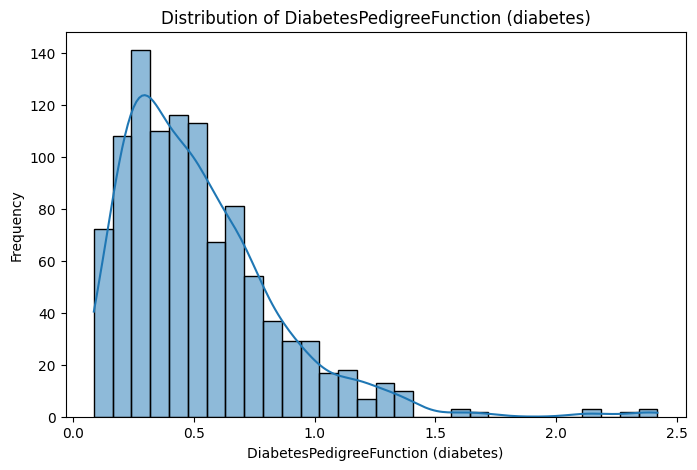

In [5]:
# 2.Understanding the 'DiabetesPedigreeFunction' column
# Display descriptive statistics for 'diabetes'
print("Descriptive statistics for 'diabetes' column:")
display(diab_data3['DiabetesPedigreeFunction'].describe())

# Visualize the distribution of 'glyhd'
plt.figure(figsize=(8, 5))
sns.histplot(diab_data3['DiabetesPedigreeFunction'], kde=True)
plt.title('Distribution of DiabetesPedigreeFunction (diabetes)')
plt.xlabel('DiabetesPedigreeFunction (diabetes)')
plt.ylabel('Frequency')
plt.show()

In [6]:
# 3 Exploring nan in the data
print(diab_data3.info())
diab_data3.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1035 entries, 0 to 1034
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               1035 non-null   int64  
 1   Glucose                   1035 non-null   int64  
 2   BloodPressure             1035 non-null   int64  
 3   SkinThickness             1035 non-null   int64  
 4   Insulin                   1035 non-null   int64  
 5   BMI                       1035 non-null   float64
 6   DiabetesPedigreeFunction  1035 non-null   float64
 7   Age                       1035 non-null   int64  
 8   glyhb                     1035 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 72.9 KB
None


,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
glyhb,0


In [30]:
# 4 Cleaning data
# Droping rows where 'glyhb' has missing values
#diab_data3 = diab_data3.dropna(subset=['glyhb'], how='any')

In [7]:
# 5. Cheking nan in the data
print(diab_data3.info())
diab_data3.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1035 entries, 0 to 1034
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               1035 non-null   int64  
 1   Glucose                   1035 non-null   int64  
 2   BloodPressure             1035 non-null   int64  
 3   SkinThickness             1035 non-null   int64  
 4   Insulin                   1035 non-null   int64  
 5   BMI                       1035 non-null   float64
 6   DiabetesPedigreeFunction  1035 non-null   float64
 7   Age                       1035 non-null   int64  
 8   glyhb                     1035 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 72.9 KB
None


,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
glyhb,0


In [ ]:
# 6. Converting string data to number (Location, Gender, and Fram) for finding the correlattion between them
'''gender_map = {
    'Female': 0,
    'Male': 1
}
diab_data['gender'] = diab_data['gender'].map(gender_map)'''

'''location_map = {
    'Urban': 0,
    'Rural': 1
}
diab_data['location'] = diab_data['location'].map(location_map)

fram_map = {
    'No': 0,
    'Yes': 1
}
diab_data['frame'] = diab_data['frame'].map(fram_map)'''

"location_map = {\n    'Urban': 0,\n    'Rural': 1\n}\ndiab_data['location'] = diab_data['location'].map(location_map)\n\nfram_map = {\n    'No': 0,\n    'Yes': 1\n}\ndiab_data['frame'] = diab_data['frame'].map(fram_map)"

In [ ]:
# Deleting geneder column
#diab_data = diab_data.drop('gender', axis=1)
#diab_data = diab_data.drop(columns=['smoking_history'])


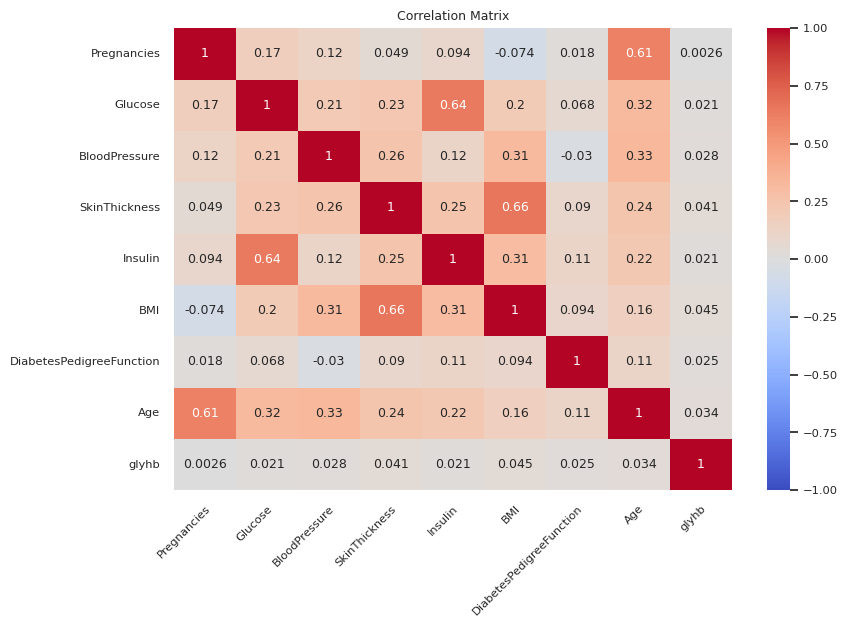

In [8]:
# 7. Showing the unnacessory columns ('smoking_history') to show clear corelationship
corr = diab_data3.corr('spearman')
plt.figure(figsize=(9,6))
sns.set(font_scale=0.75)
ax = sns.heatmap(corr, vmin=-1, center=0, vmax=1, annot=True, cmap='coolwarm')
# Rotate x-axis labels (column names)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
# Rotate y-axis labels (column names)
plt.setp(ax.get_yticklabels(), rotation=0)
plt.title('Correlation Matrix')
plt.show()

In [ ]:
# 8.1 Deleting unusfel columns that show low correlation with glyb label
'''diab_data3_corr = diab_data3.drop(['id','location', 'gender','frame'], axis =1).corr('spearman')
for col in diab_data3_corr.columns:
   if (diab_data3_corr['glyhb'].corr(diab_data3_corr[col])<=0):
    diab_data3_corr = diab_data3_corr.drop(col, axis=1)'''

In [9]:
# 8.2 This step is another way to drop columns
# Dropping uncorelated columns to the glyhb column
diab_data3_corr = diab_data3.copy() # Make a copy to avoid modifying the original DataFrame
x = 0
for col in diab_data3_corr.columns:
   if col == 'glyhb': # Skip the target column itself
       print(f"Skipping target column: '{col}'")
       continue

   # Calculate correlation, handling potential NaN values if a column is all NaNs after dropna()
   if diab_data3_corr[col].isnull().all(): # Check if column is entirely NaN
       correlation = 0 # Or handle as appropriate, e.g., drop it always
   else:
       correlation = diab_data3_corr['glyhb'].corr(diab_data3_corr[col])

   if (correlation <= 0.0):
    diab_data3_corr = diab_data3_corr.drop(col, axis=1)
    x = x+1
    print(f"True: Column '{col}' dropped due to correlation <= 0 (Correlation: {correlation:.2f})")
   else:
    print(f"False: Column '{col}' kept (Correlation: {correlation:.2f})")
print(f"Total columns dropped: {x}")


False: Column 'Pregnancies' kept (Correlation: 0.01)
False: Column 'Glucose' kept (Correlation: 0.02)
False: Column 'BloodPressure' kept (Correlation: 0.03)
False: Column 'SkinThickness' kept (Correlation: 0.04)
False: Column 'Insulin' kept (Correlation: 0.03)
False: Column 'BMI' kept (Correlation: 0.05)
False: Column 'DiabetesPedigreeFunction' kept (Correlation: 0.01)
False: Column 'Age' kept (Correlation: 0.04)
Skipping target column: 'glyhb'
Total columns dropped: 0


In [ ]:
# 8.3 Dropping all zero values from columns except glyhb
'''x = 0
for col in diab_data3.columns:
   if col == 'glyhb': # Skip the target column itself
       print(f"Skipping target column: '{col}'")
       continue
       # Validate column existence
   if col in diab_data3.columns:
        # Keep only rows where the column is NOT zero
        diab_data3 = diab_data3[diab_data3[col] != 0].reset_index(drop=True)
   else:
        raise ValueError(f"Column '{col}' does not exist in DataFrame.")'''

'x = 0\nfor col in diab_data3.columns:\n   if col == \'glyhb\': # Skip the target column itself\n       print(f"Skipping target column: \'{col}\'")\n       continue\n       # Validate column existence\n   if col in diab_data3.columns:\n        # Keep only rows where the column is NOT zero\n        diab_data3 = diab_data3[diab_data3[col] != 0].reset_index(drop=True)\n   else:\n        raise ValueError(f"Column \'{col}\' does not exist in DataFrame.")'

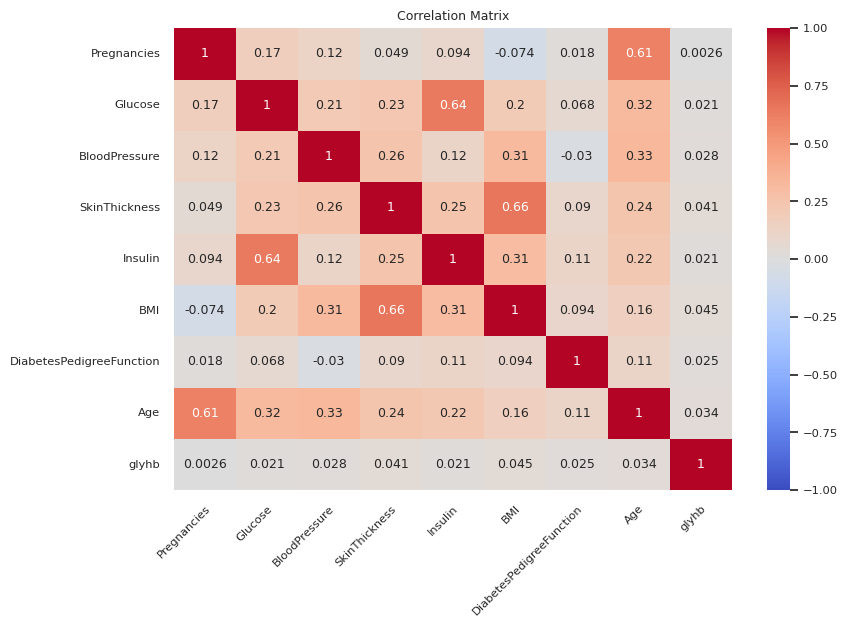

In [10]:
# 9. Exploring the correlation map with glyb for double check
corr = diab_data3_corr.corr('spearman')
plt.figure(figsize=(9,6))
sns.set(font_scale=0.75)
ax = sns.heatmap(corr, vmin=-1, center=0, vmax=1, annot=True, cmap='coolwarm')
# Rotate x-axis labels (column names)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
# Rotate y-axis labels (column names)
plt.setp(ax.get_yticklabels(), rotation=0)
plt.title('Correlation Matrix')
plt.show()

In [11]:
# 10. Building data for the model

# First, ensure consistency by dropping rows with any NaN values from the relevant columns
# This step ensures X and y will have the same number of samples.
diab_data3_cleaned = diab_data3_corr.dropna(how='any')

X3 = diab_data3_cleaned.drop('glyhb', axis=1)
y3 = diab_data3_cleaned['glyhb']

# Convert target to binary (1 for diabetes, 0 for no diabetes)
# Using a common clinical threshold for HbA1c: >= 6.5% for diabetes
#y_binary = (y >= 6.5).astype(int)
y3_binary = (y3 > np.median(y3)).astype(int)

# Spliting data
X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, test_size= 0.2, random_state= 42)

# Normalizing data
scaler = StandardScaler()
X3_train = scaler.fit_transform(X3_train)
X3_test = scaler.transform(X3_test)

The above graph shows that the data is impalanced where about 685 outof 2000 are postive (Truely dignoced with diabets)

In [21]:
# 11. Building the Logistic Regression model
model3 = LogisticRegression()
model3.fit(X3_train, y3_train)

LogisticRegression()

In [22]:
# 12. Predict on test data
y3_pred = model3.predict(X3_test)

# Accuracy score
accuracy = accuracy_score(y3_test, y3_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

# Confusion Matrix and Classification Report
print("Confusion Matrix:\n", confusion_matrix(y3_test, y3_pred))
print("\nClassification Report:\n", classification_report(y3_test, y3_pred))

Accuracy: 63.29%
Confusion Matrix:
 [[131   0]
 [ 76   0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.63      1.00      0.78       131
           1       0.00      0.00      0.00        76

    accuracy                           0.63       207
   macro avg       0.32      0.50      0.39       207
weighted avg       0.40      0.63      0.49       207



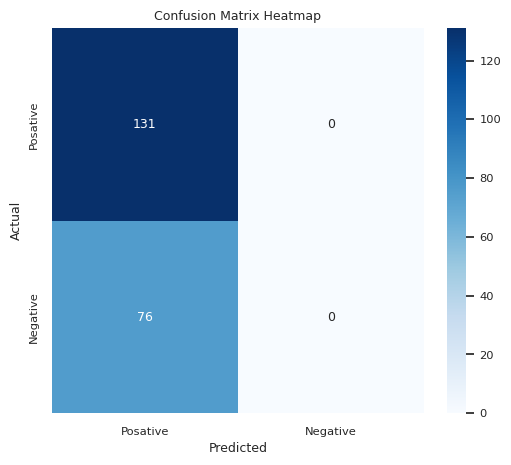

In [14]:
# 14  Plot confusion matrix as heatmap
import seaborn as sns

cm = confusion_matrix(y3_test, y3_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Posative', 'Negative'], yticklabels=['Posative', 'Negative'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap')
plt.show()

In [15]:
# 15. Printing the resuls (this source for comparing the results with program in the Applied Machine Learning with Python book, page 62)

print('Prediction:', y3_pred[64], y3_pred[10], y3_pred[25])
print('Raw Model Output X_test: ',
      (model3.coef_@ X3_test[1]+model3.intercept_),
      (model3.coef_@X3_test[10]+model3.intercept_),
      (model3.coef_@X3_test[25] + model3.intercept_))

Prediction: 0 0 0
Raw Model Output X_test:  [-0.87525487] [-0.72155098] [-0.67541112]


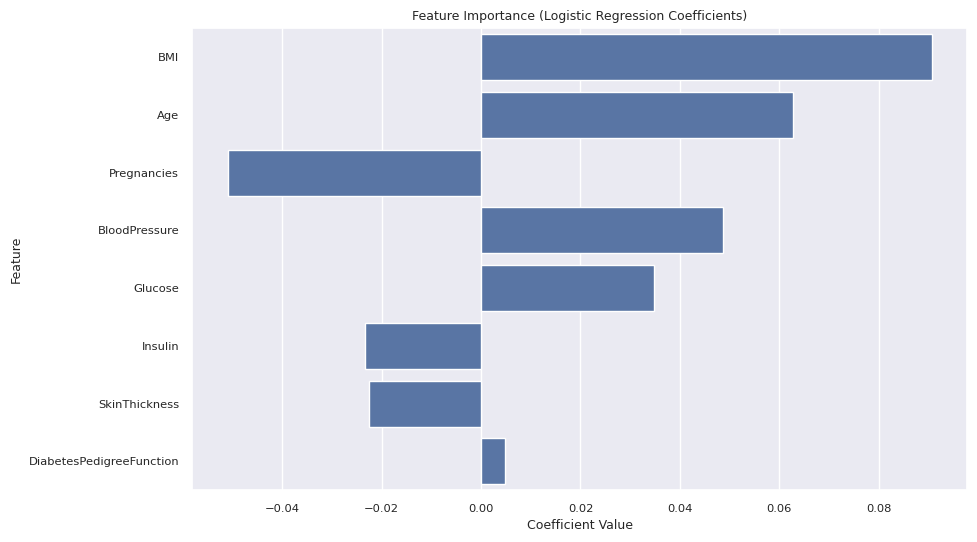

In [16]:
# 16. Coefficients for each feature
feature_importance = pd.DataFrame({'feature': X3.columns, 'coefficient': model3.coef_[0]})
feature_importance['abs_coefficient'] = abs(feature_importance['coefficient'])
feature_importance = feature_importance.sort_values(by='abs_coefficient', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='coefficient', y='feature', data=feature_importance)
plt.title('Feature Importance (Logistic Regression Coefficients)')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.show()

AUC Score: 0.4893


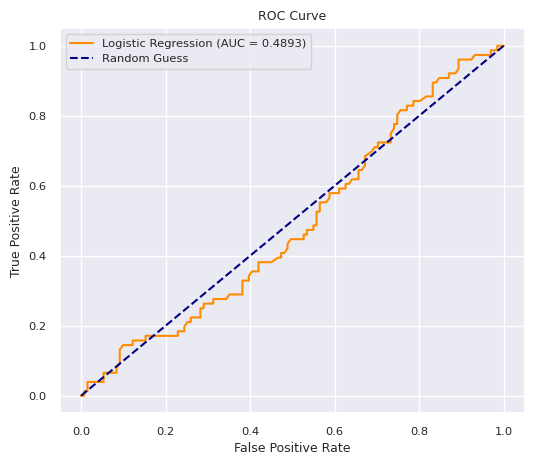

In [17]:
# 17 Plorint area under curve
#Predict probabilities for the positive class
y3_probs = model3.predict_proba(X3_test)[:, 1]

    # Calculate AUC
from sklearn.metrics import roc_auc_score, roc_curve
auc_score = roc_auc_score(y3_test, y3_probs)
print(f"AUC Score: {auc_score:.4f}")

# Optional: Plot ROC curve
fpr, tpr, thresholds = roc_curve(y3_test, y3_probs)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc_score:.4f})', color='darkorange',  )
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess', color='navy')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

Extracting individual values from the confusion matrix:

*  Sensitivity / Recall: The proportion of actual sick patients correctly identified. we want this to be close to 100%.
* Specificity: The proportion of actual healthy people correctly identified as healthy


In [18]:
# 18 Measuring sensitivity and specificity
tn, fp, fn, tp = confusion_matrix(y3_test, y3_pred).ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print(f"Sensitivity (True Positive Rate): {sensitivity:.2f}")
print(f"Specificity (True Negative Rate): {specificity:.2f}")

Sensitivity (True Positive Rate): 0.00
Specificity (True Negative Rate): 1.00


# 4th Logistic Regression

##    Building LR model

In [19]:
# 1. Importing dataset
# Please upload 'diabetes.csv' to your Colab session, or provide the correct path.
diab_data4= pd.read_csv('/content/sample_data/Db.csv')
diab_data4.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,1,89,66,23,94,28.1,0.167,21,0
3,0,137,40,35,168,43.1,2.288,33,1
4,3,78,50,32,88,31.0,0.248,26,1


Descriptive statistics for 'diabetes' column:


,DiabetesPedigreeFunction
count,532.000000
mean,0.502966
std,0.344546
min,0.085000
25%,0.258750
50%,0.416000
75%,0.658500
max,2.420000


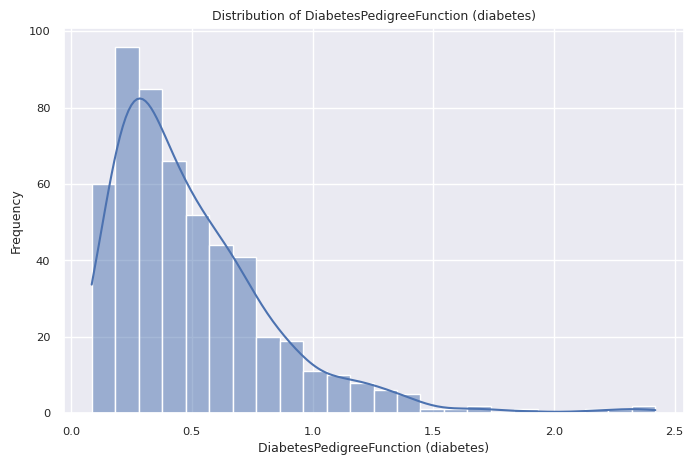

In [20]:
# 2.Understanding the 'diabetes' column
# Display descriptive statistics for 'diabetes'
print("Descriptive statistics for 'diabetes' column:")
display(diab_data4['DiabetesPedigreeFunction'].describe())

# Visualize the distribution of 'glyhd'
plt.figure(figsize=(8, 5))
sns.histplot(diab_data4['DiabetesPedigreeFunction'], kde=True)
plt.title('Distribution of DiabetesPedigreeFunction (diabetes)')
plt.xlabel('DiabetesPedigreeFunction (diabetes)')
plt.ylabel('Frequency')
plt.show()

In [21]:
# 3 Exploring nan in the data
print(diab_data4.info())
diab_data4.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 532 entries, 0 to 531
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               532 non-null    int64  
 1   Glucose                   532 non-null    int64  
 2   BloodPressure             532 non-null    int64  
 3   SkinThickness             532 non-null    int64  
 4   Insulin                   532 non-null    int64  
 5   BMI                       532 non-null    float64
 6   DiabetesPedigreeFunction  532 non-null    float64
 7   Age                       532 non-null    int64  
 8   Outcome                   532 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 37.5 KB
None


,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [22]:
# 3.1 Rename the boood_glucose_level to glyhd
diab_data4 = diab_data4.rename(columns={'Outcome': 'glyhb'})
diab_data4.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,glyhb
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,1,89,66,23,94,28.1,0.167,21,0
3,0,137,40,35,168,43.1,2.288,33,1
4,3,78,50,32,88,31.0,0.248,26,1


In [23]:
# 4 Cleaning data
# Droping rows where 'glyhb' has missing values
diab_data4 = diab_data4.dropna(subset=['glyhb'], how='any')

In [20]:
# 5. Cheking nan in the data
print(diab_data4.info())
diab_data4.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 532 entries, 0 to 531
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               532 non-null    int64  
 1   Glucose                   532 non-null    int64  
 2   BloodPressure             532 non-null    int64  
 3   SkinThickness             532 non-null    int64  
 4   Insulin                   532 non-null    int64  
 5   BMI                       532 non-null    float64
 6   DiabetesPedigreeFunction  532 non-null    float64
 7   Age                       532 non-null    int64  
 8   glyhb                     532 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 37.5 KB
None


,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
glyhb,0


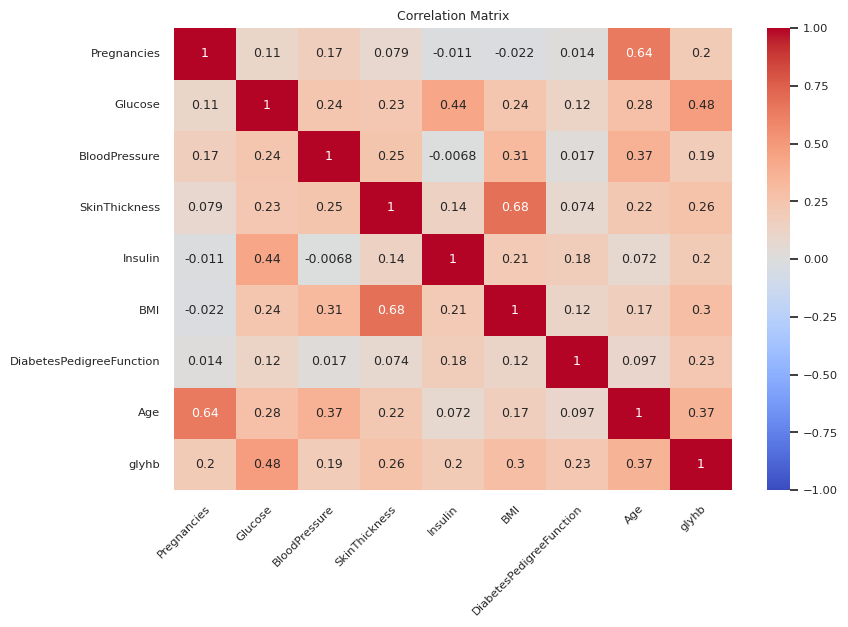

In [24]:
# 7. Showing the unnacessory columns ('smoking_history') to show clear corelationship

corr = diab_data4.corr('spearman')
plt.figure(figsize=(9,6))
sns.set(font_scale=0.75)
ax = sns.heatmap(corr, vmin=-1, center=0, vmax=1, annot=True, cmap='coolwarm')
# Rotate x-axis labels (column names)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
# Rotate y-axis labels (column names)
plt.setp(ax.get_yticklabels(), rotation=0)
plt.title('Correlation Matrix')
plt.show()

In [25]:
# 8. This step is another way to drop columns
# Dropping uncorelated columns to the glyhb column
diab_data4_corr = diab_data4.copy() # Make a copy to avoid modifying the original DataFrame
x = 0
for col in diab_data4_corr.columns:
   if col == 'glyhb': # Skip the target column itself
       print(f"Skipping target column: '{col}'")
       continue

   # Calculate correlation, handling potential NaN values if a column is all NaNs after dropna()
   if diab_data4_corr[col].isnull().all(): # Check if column is entirely NaN
       correlation = 0 # Or handle as appropriate, e.g., drop it always
   else:
       correlation = diab_data4_corr['glyhb'].corr(diab_data4_corr[col])

   if (correlation <= 0.0):
    diab_data4_corr = diab_data4_corr.drop(col, axis=1)
    x = x+1
    print(f"True: Column '{col}' dropped due to correlation <= 0 (Correlation: {correlation:.2f})")
   else:
    print(f"False: Column '{col}' kept (Correlation: {correlation:.2f})")
print(f"Total columns dropped: {x}")

False: Column 'Pregnancies' kept (Correlation: 0.25)
False: Column 'Glucose' kept (Correlation: 0.50)
False: Column 'BloodPressure' kept (Correlation: 0.18)
False: Column 'SkinThickness' kept (Correlation: 0.25)
False: Column 'Insulin' kept (Correlation: 0.21)
False: Column 'BMI' kept (Correlation: 0.30)
False: Column 'DiabetesPedigreeFunction' kept (Correlation: 0.23)
False: Column 'Age' kept (Correlation: 0.32)
Skipping target column: 'glyhb'
Total columns dropped: 0


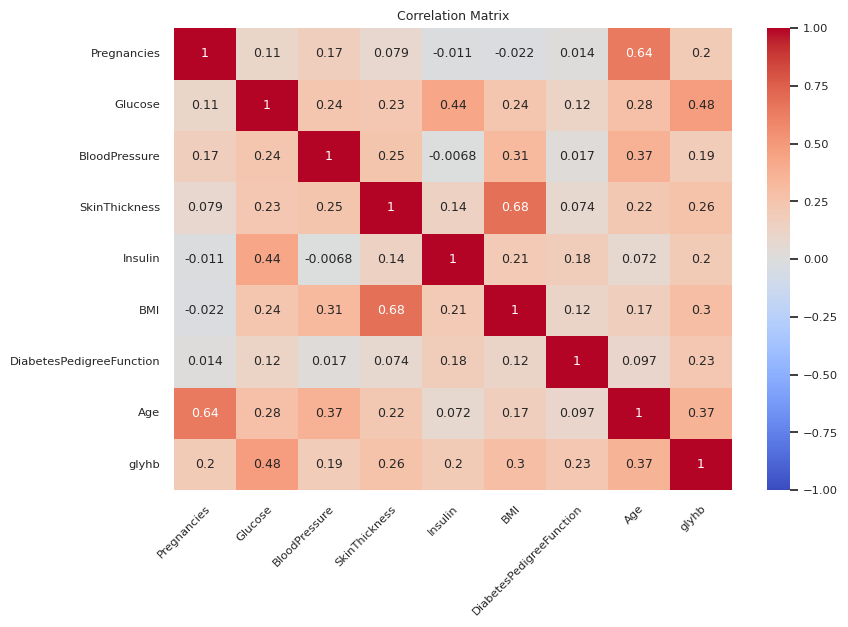

In [26]:
# 9. Exploring the correlation map with glyb for double check
corr = diab_data4_corr.corr('spearman')
plt.figure(figsize=(9,6))
sns.set(font_scale=0.75)
ax = sns.heatmap(corr, vmin=-1, center=0, vmax=1, annot=True, cmap='coolwarm')
# Rotate x-axis labels (column names)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
# Rotate y-axis labels (column names)
plt.setp(ax.get_yticklabels(), rotation=0)
plt.title('Correlation Matrix')
plt.show()

In [24]:
# Comparing correlation of datasets that incaluded in the model 3 and model 4
# Exploring the correlation of features in the Germany data of the model 3
diab_data3.corr(numeric_only=True)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,glyhb
Pregnancies,1.000000,0.183272,0.191951,0.104512,0.075418,-0.023963,0.025018,0.661358,0.012303
Glucose,0.183272,1.000000,0.182876,0.221311,0.560635,0.218398,0.130361,0.306974,0.020272
BloodPressure,0.191951,0.182876,1.000000,0.253442,0.098907,0.304532,0.009801,0.305666,0.028762
SkinThickness,0.104512,0.221311,0.253442,1.000000,0.205032,0.645092,0.160326,0.203545,0.043672
Insulin,0.075418,0.560635,0.098907,0.205032,1.000000,0.253266,0.134679,0.142755,0.030398
BMI,-0.023963,0.218398,0.304532,0.645092,0.253266,1.000000,0.151762,0.078557,0.050098
DiabetesPedigreeFunction,0.025018,0.130361,0.009801,0.160326,0.134679,0.151762,1.000000,0.105085,0.012553
Age,0.661358,0.306974,0.305666,0.203545,0.142755,0.078557,0.105085,1.000000,0.036264
glyhb,0.012303,0.020272,0.028762,0.043672,0.030398,0.050098,0.012553,0.036264,1.000000


In [25]:
# Exploring the correlation of the feature in the Db data of the model 4
diab_data4.corr(numeric_only=True)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,glyhb
Pregnancies,1.000000,0.125330,0.204663,0.095085,-0.006568,0.008576,0.007435,0.640747,0.252586
Glucose,0.125330,1.000000,0.219178,0.226590,0.459905,0.247079,0.165817,0.278907,0.503614
BloodPressure,0.204663,0.219178,1.000000,0.226072,0.007052,0.307357,0.008047,0.346939,0.183432
SkinThickness,0.095085,0.226590,0.226072,1.000000,0.126240,0.647422,0.118636,0.161336,0.254874
Insulin,-0.006568,0.459905,0.007052,0.126240,1.000000,0.191168,0.151531,0.081126,0.212204
BMI,0.008576,0.247079,0.307357,0.647422,0.191168,1.000000,0.151107,0.073438,0.300901
DiabetesPedigreeFunction,0.007435,0.165817,0.008047,0.118636,0.151531,0.151107,1.000000,0.071654,0.233074
Age,0.640747,0.278907,0.346939,0.161336,0.081126,0.073438,0.071654,1.000000,0.315097
glyhb,0.252586,0.503614,0.183432,0.254874,0.212204,0.300901,0.233074,0.315097,1.000000


In [27]:
# 10. Building data for the model

# First, ensure consistency by dropping rows with any NaN values from the relevant columns
# This step ensures X and y will have the same number of samples.
diab_data4_cleaned = diab_data4_corr.dropna(how='any')

X = diab_data4_cleaned.drop('glyhb', axis=1)
y = diab_data4_cleaned['glyhb']

# Convert target to binary (1 for diabetes, 0 for no diabetes)
# Using a common clinical threshold for HbA1c: >= 6.5% for diabetes
#y_binary = (y >= 6.5).astype(int)
y_binary = (y > np.median(y)).astype(int)

# Spliting data
X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size= 0.3, random_state= 42)

# Normalizing data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

The above graph shows that the dataset is implanced where about 270 are posative (turely dignosed with diabetes)

In [28]:
# 11. Building the Logistic Regression model
model4 = LogisticRegression()
model4.fit(X_train, y_train)

LogisticRegression()

In [29]:
# 12. Predict on test data
y_pred = model4.predict(X_test)

# Accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

# Confusion Matrix and Classification Report
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 76.88%
Confusion Matrix:
 [[96 15]
 [22 27]]

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.86      0.84       111
           1       0.64      0.55      0.59        49

    accuracy                           0.77       160
   macro avg       0.73      0.71      0.72       160
weighted avg       0.76      0.77      0.76       160



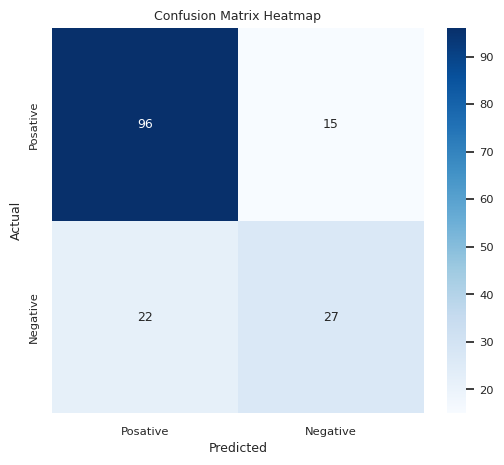

In [30]:
# 13.  Plot confusion matrix as heatmap
import seaborn as sns


cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Posative', 'Negative'], yticklabels=['Posative', 'Negative'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap')
plt.show()

In [31]:
# 14. Printing the resuls (this source for comparing the results with program in the Applied Machine Learning with Python book, page 62)

print('Prediction:', y_pred[1], y_pred[30], y_pred[75])
print('Raw Model Output X_test: ',
      (model4.coef_@ X_test[1]+model4.intercept_),
      (model4.coef_@X_test[10]+model4.intercept_),
      (model4.coef_@X_test[75] + model4.intercept_))

Prediction: 0 1 0
Raw Model Output X_test:  [-1.49209638] [-0.89324076] [-4.10108069]


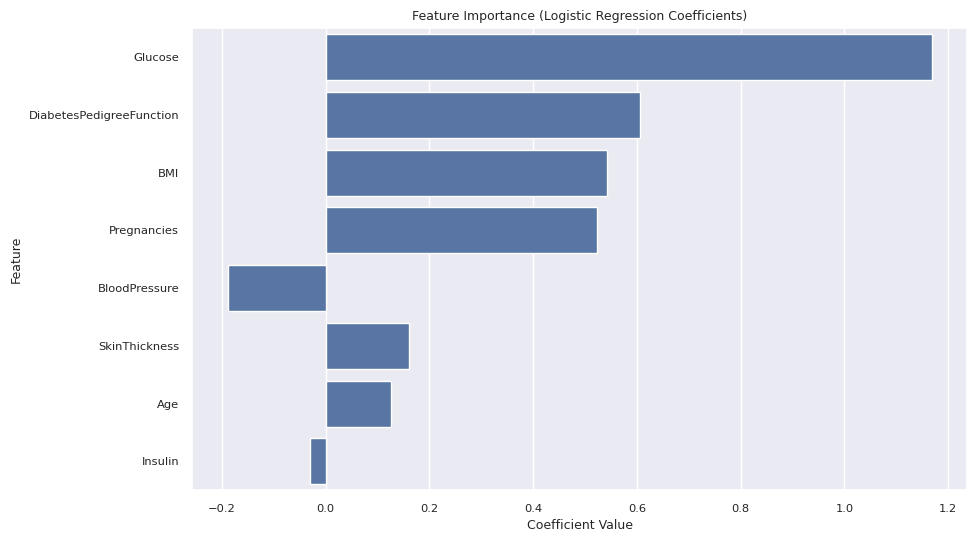

In [32]:
# 15. Coefficients for each feature
feature_importance = pd.DataFrame({'feature': X.columns, 'coefficient': model4.coef_[0]})
feature_importance['abs_coefficient'] = abs(feature_importance['coefficient'])
feature_importance = feature_importance.sort_values(by='abs_coefficient', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='coefficient', y='feature', data=feature_importance)
plt.title('Feature Importance (Logistic Regression Coefficients)')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.show()

AUC Score: 0.8417


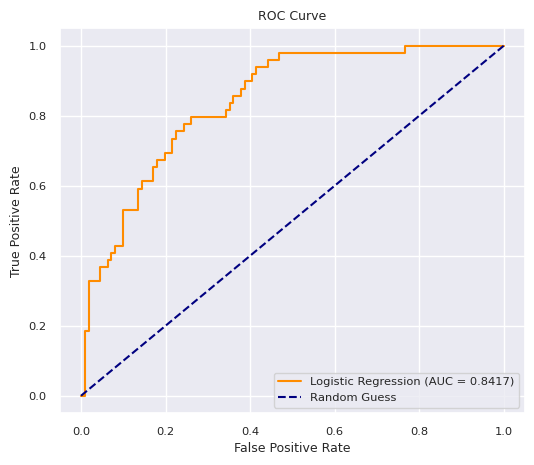

In [33]:
# 16. Plorint area under curve
#Predict probabilities for the positive class
y_probs = model4.predict_proba(X_test)[:, 1]

    # Calculate AUC
from sklearn.metrics import roc_auc_score, roc_curve
auc_score = roc_auc_score(y_test, y_probs)
print(f"AUC Score: {auc_score:.4f}")

# Optional: Plot ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc_score:.4f})', color='darkorange',  )
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess', color='navy')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

Extracting individual values from the confusion matrix:

*  Sensitivity / Recall: The proportion of actual sick patients correctly identified. we want this to be close to 100%.
* Specificity: The proportion of actual healthy people correctly identified as healthy




In [34]:
# 18 Measuring sensitivity and specificity
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print(f"Sensitivity (True Positive Rate): {sensitivity:.2f}")
print(f"Specificity (True Negative Rate): {specificity:.2f}")

Sensitivity (True Positive Rate): 0.55
Specificity (True Negative Rate): 0.86


# 5 Testing Datasets

In [ ]:
import seaborn as sns

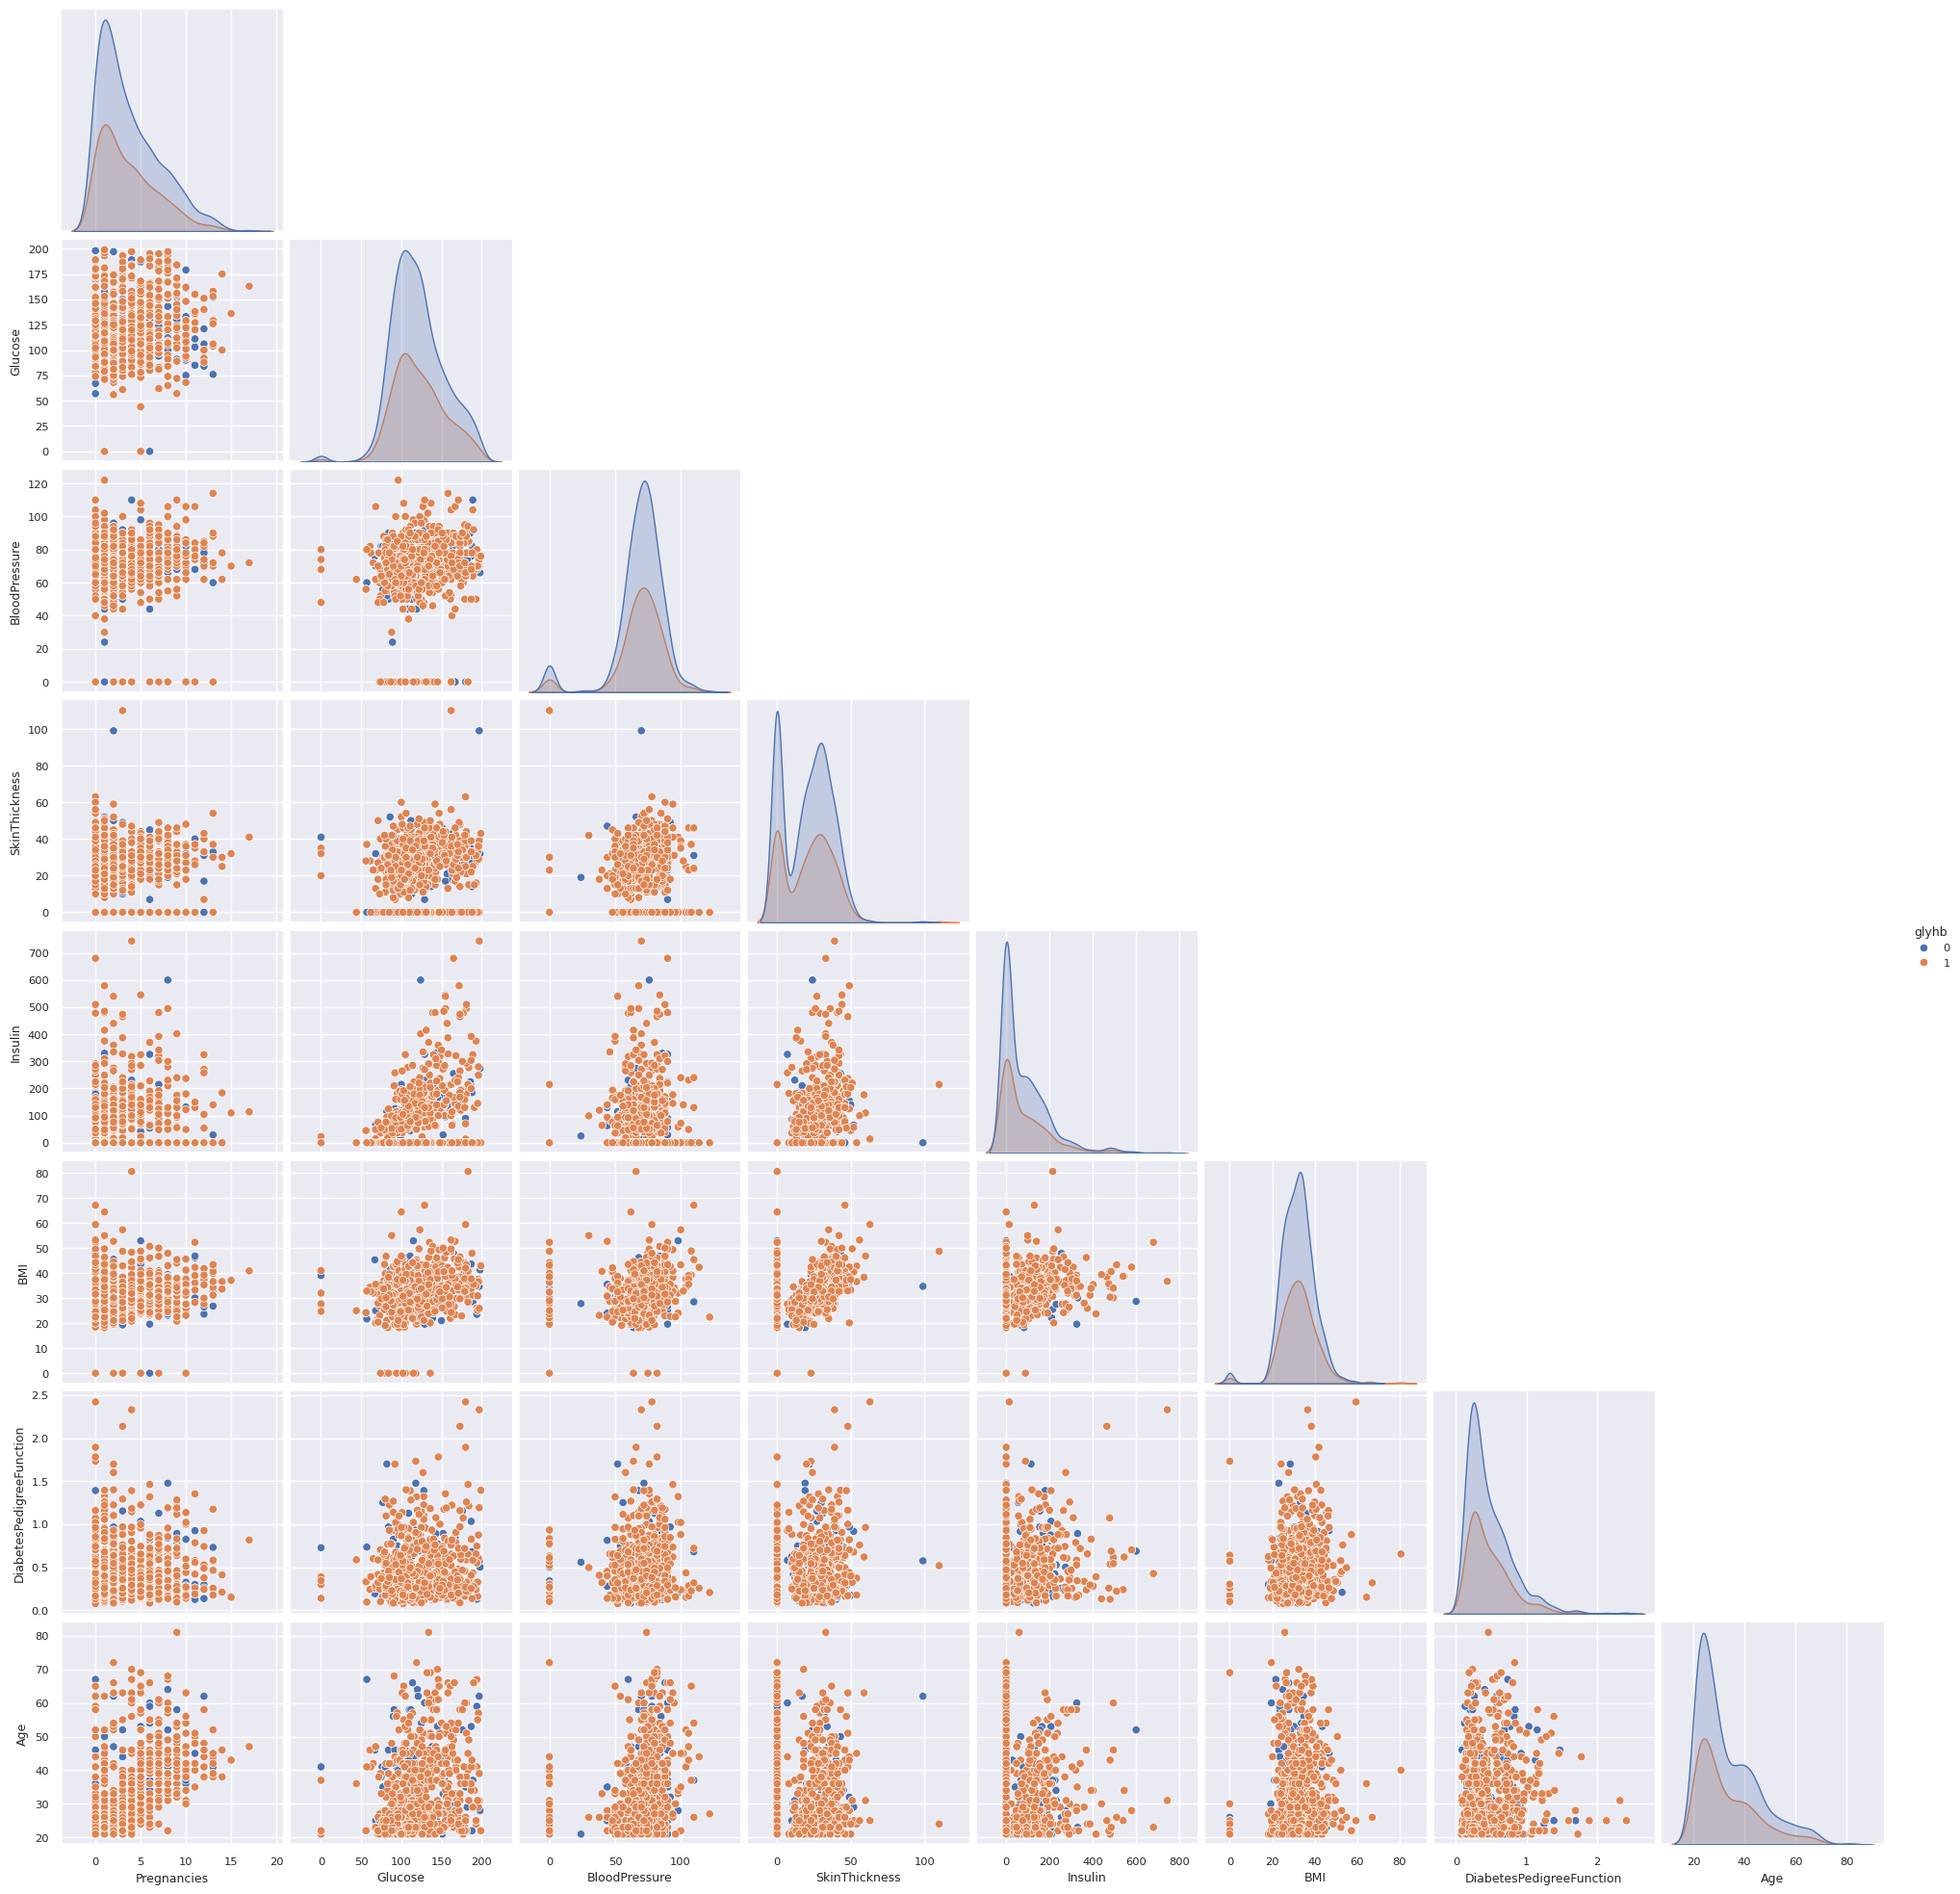

In [ ]:
sns.pairplot(diab_data3, hue='glyhb', corner= True);

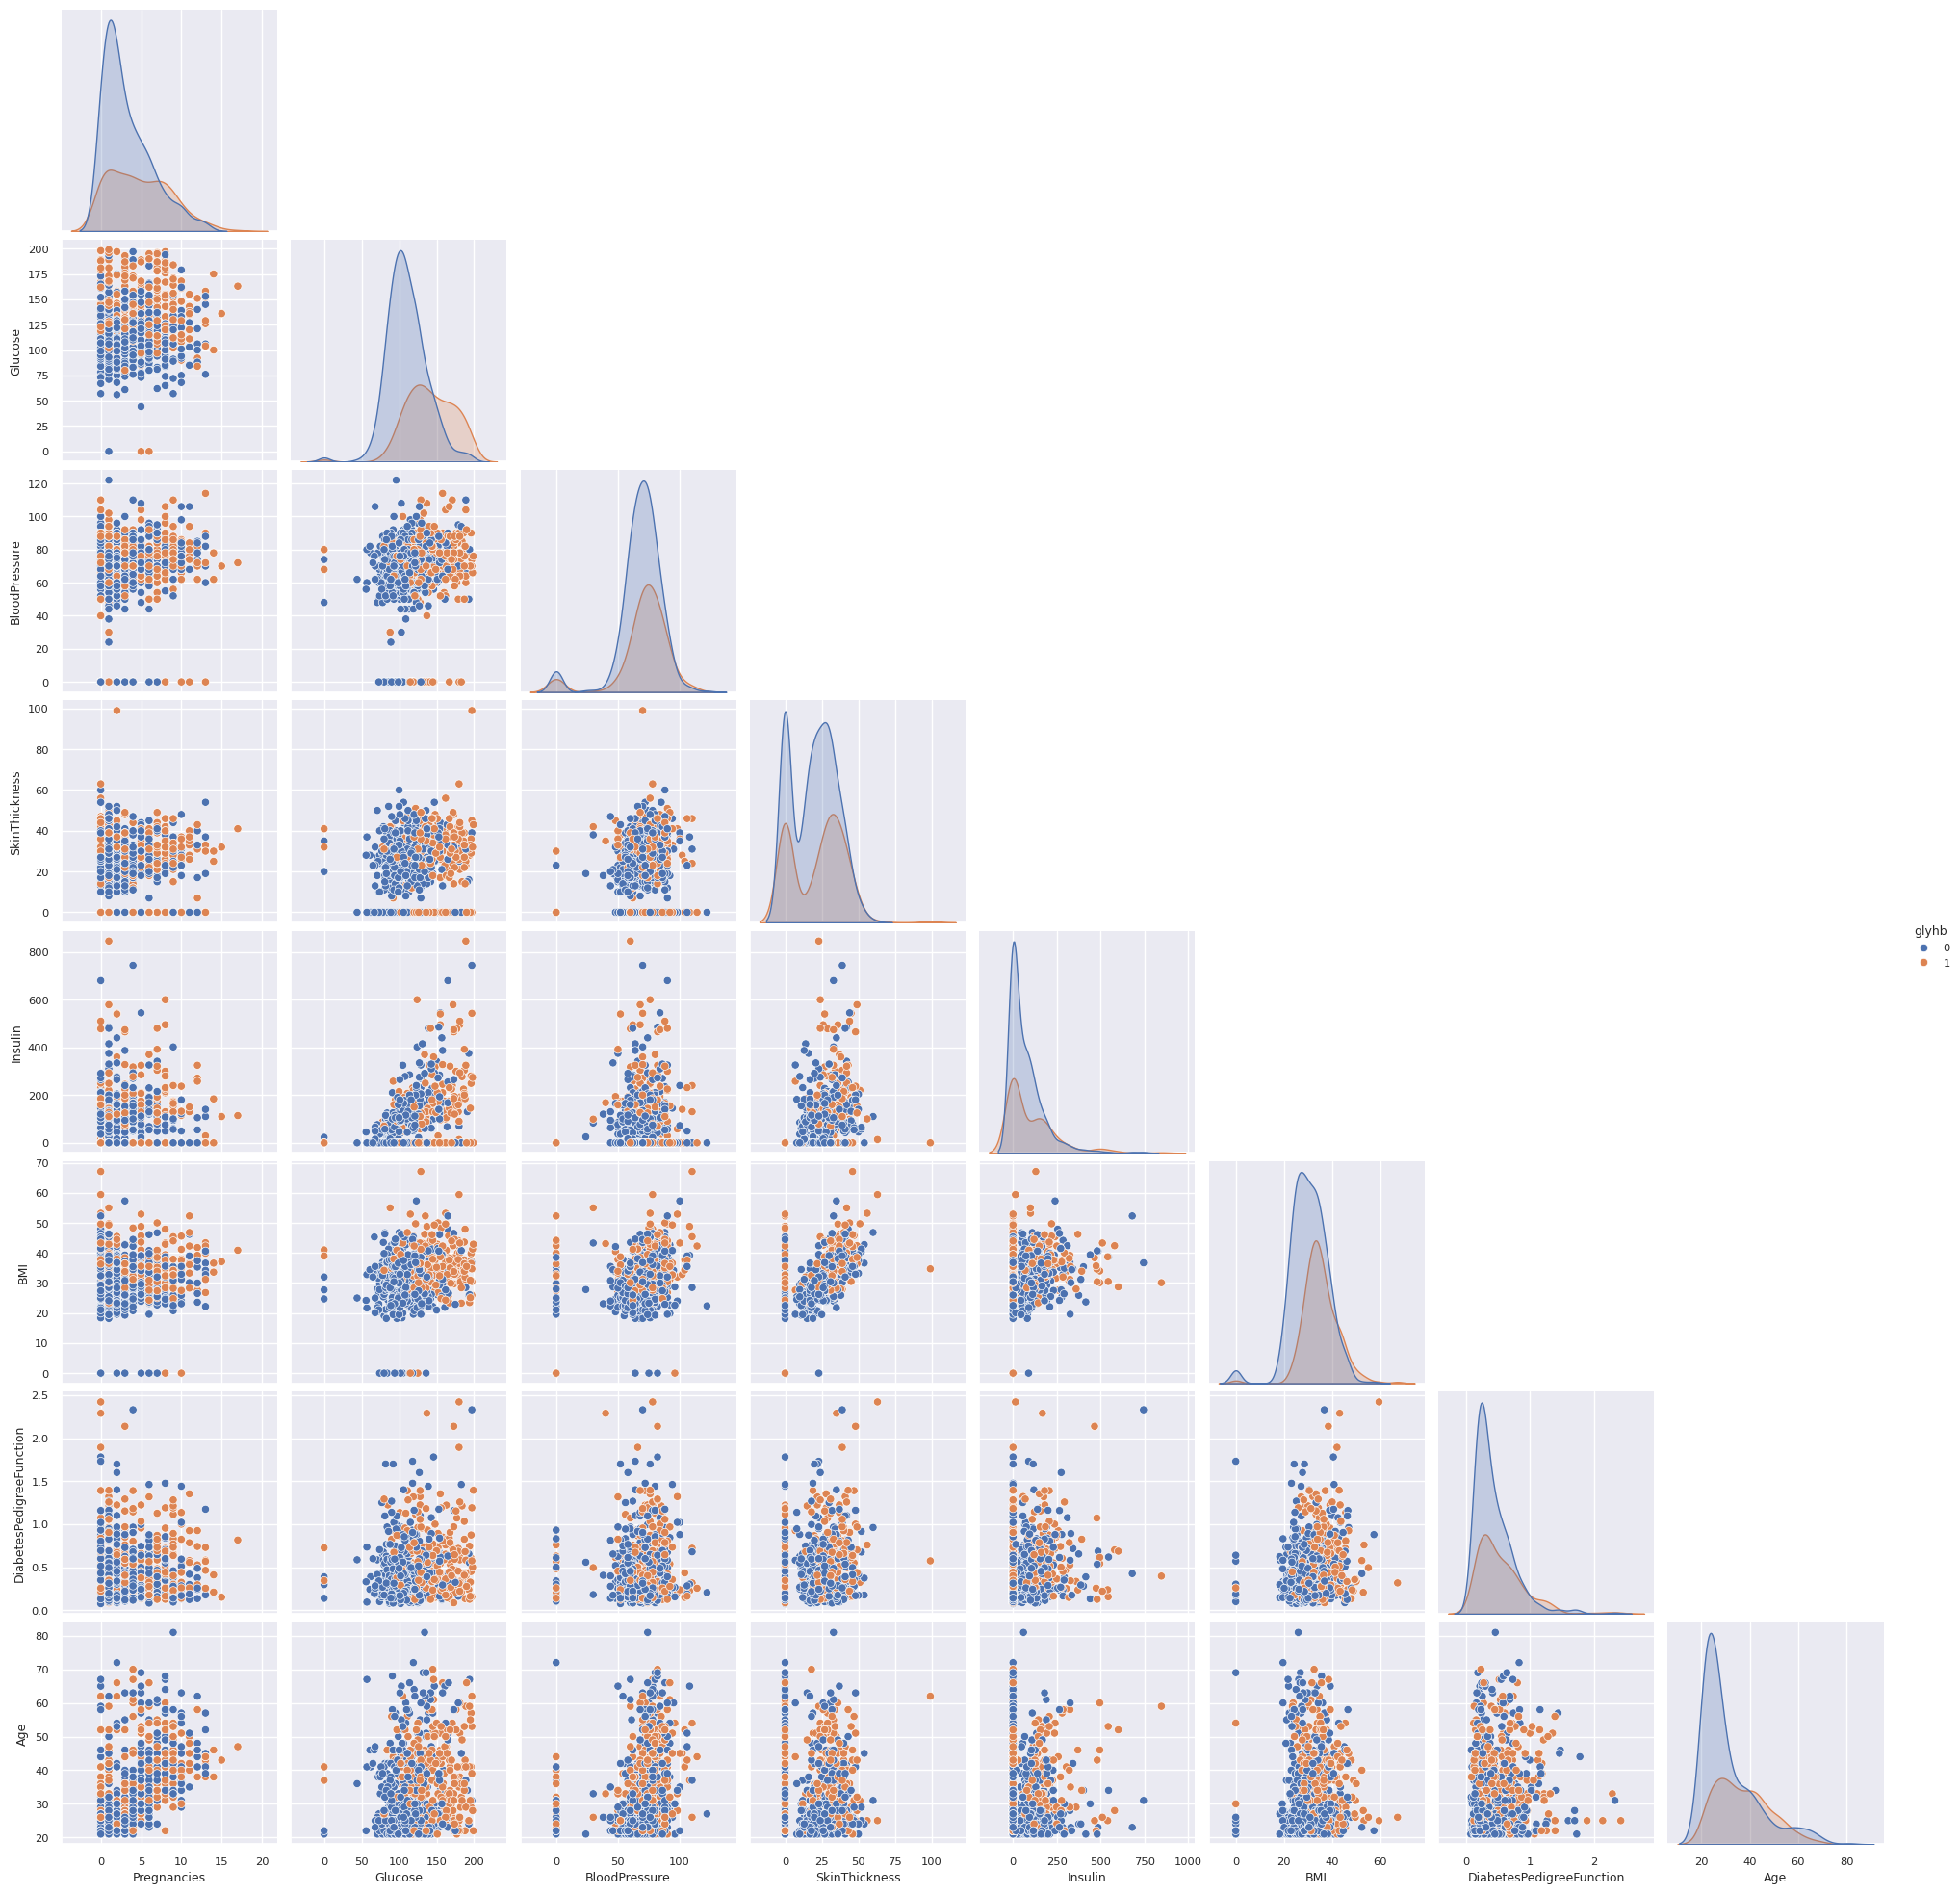

In [ ]:
sns.pairplot(diab_data4, hue='glyhb', corner= True);





-------------------------
# This part is for demo test

---



In [ ]:
from sklearn.datasets import load_diabetes
diabetes = load_diabetes()
diabetes.target[:3]
diabetes.data.shape

(442, 10)

In [ ]:
diabetes.data[:3]

array([[ 0.03807591,  0.05068012,  0.06169621,  0.02187239, -0.0442235 ,
        -0.03482076, -0.04340085, -0.00259226,  0.01990749, -0.01764613],
       [-0.00188202, -0.04464164, -0.05147406, -0.02632753, -0.00844872,
        -0.01916334,  0.07441156, -0.03949338, -0.06833155, -0.09220405],
       [ 0.08529891,  0.05068012,  0.04445121, -0.00567042, -0.04559945,
        -0.03419447, -0.03235593, -0.00259226,  0.00286131, -0.02593034]])

# 6 Linear Regression

Mean squared error: 9.54
Coefficient of determination: 0.33


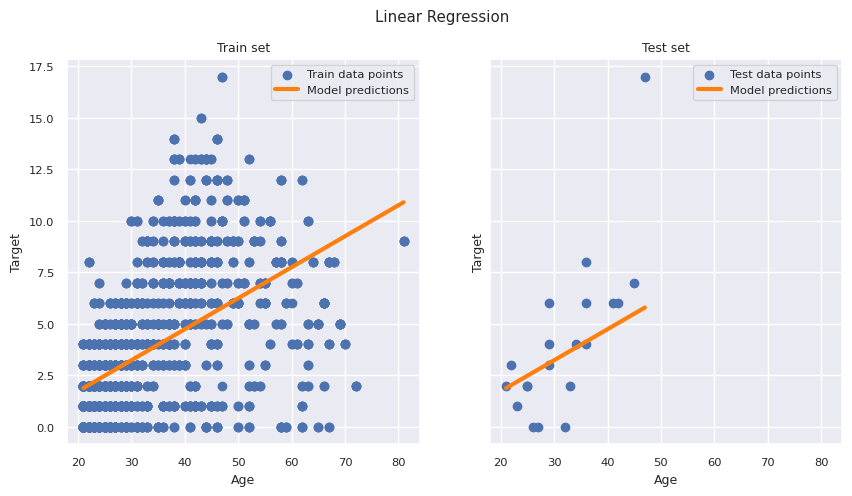

In [ ]:
# Using Linear Reagression for testing the corelatino between two selected features in both datasets
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split


'''X, y = load_diabetes(return_X_y=True)
X = X[:, [2]]  # Use only one feature, which is 'bmi' at index 2'''

# Ensure X is a DataFrame with a single column
X = diab_data3[['Age']]
y = diab_data3['Pregnancies']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=20, shuffle=False)

from sklearn.linear_model import LinearRegression

regressor = LinearRegression().fit(X_train, y_train)

from sklearn.metrics import mean_squared_error, r2_score

y_pred = regressor.predict(X_test)

print(f"Mean squared error: {mean_squared_error(y_test, y_pred):.2f}")
print(f"Coefficient of determination: {r2_score(y_test, y_pred):.2f}")

import matplotlib.pyplot as plt
import pandas as pd

fig, ax = plt.subplots(ncols=2, figsize=(10, 5), sharex=True, sharey=True)

# Choose the correct feature for plotting
feature_name_to_plot = 'Age'

# Training data plot
# Access the single column of the DataFrame using its name
ax[0].scatter(X_train[feature_name_to_plot], y_train, label="Train data points")

# To plot a smooth regression line, sort the feature values and their corresponding predictions
train_data_for_plot = pd.DataFrame({
    feature_name_to_plot: X_train[feature_name_to_plot],
    'prediction': regressor.predict(X_train)
}).sort_values(by=feature_name_to_plot)

ax[0].plot(
    train_data_for_plot[feature_name_to_plot],
    train_data_for_plot['prediction'],
    linewidth=3,
    color="tab:orange",
    label="Model predictions",
)
ax[0].set(xlabel=feature_name_to_plot, ylabel="Target", title="Train set")
ax[0].legend()

# Test data plot
# Access the single column of the DataFrame using its name
ax[1].scatter(X_test[feature_name_to_plot], y_test, label="Test data points")

# To plot a smooth regression line for test data
test_data_for_plot = pd.DataFrame({
    feature_name_to_plot: X_test[feature_name_to_plot],
    'prediction': y_pred
}).sort_values(by=feature_name_to_plot)

ax[1].plot(
    test_data_for_plot[feature_name_to_plot],
    test_data_for_plot['prediction'],
    linewidth=3,
    color="tab:orange",
    label="Model predictions",
)
ax[1].set(xlabel=feature_name_to_plot, ylabel="Target", title="Test set")
ax[1].legend()

fig.suptitle("Linear Regression")

plt.show()

<Axes: >

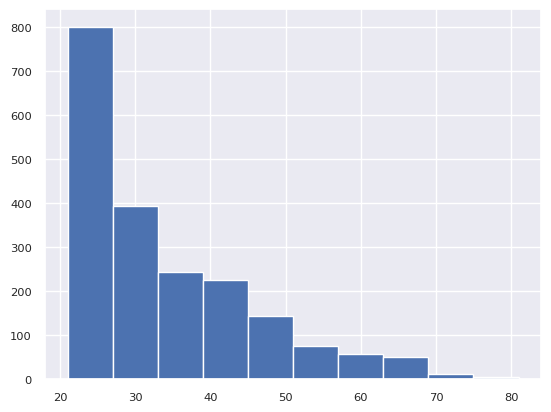

In [ ]:
diab_data3['Age'].hist()

<Axes: >

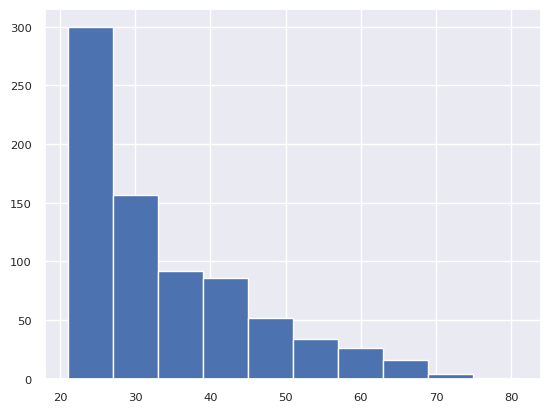

In [ ]:
diab_data4['Age'].hist()

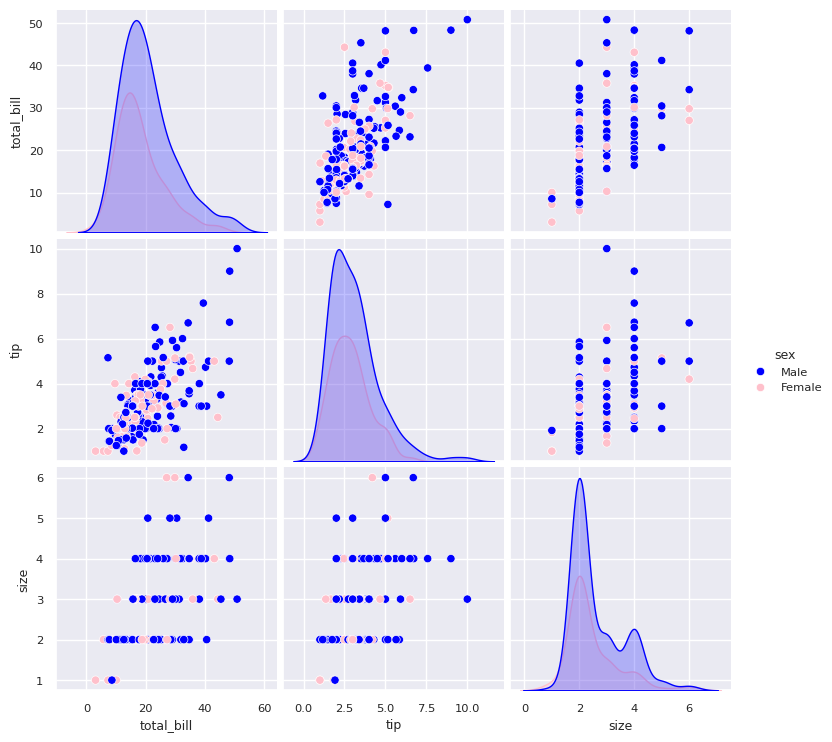

In [ ]:
# Load example dataset
tips = sns.load_dataset("tips")
# Create a pairplot with color coding by 'sex'
sns.pairplot(tips, hue="sex", palette={"Male": "blue", "Female": "pink"})
plt.show()

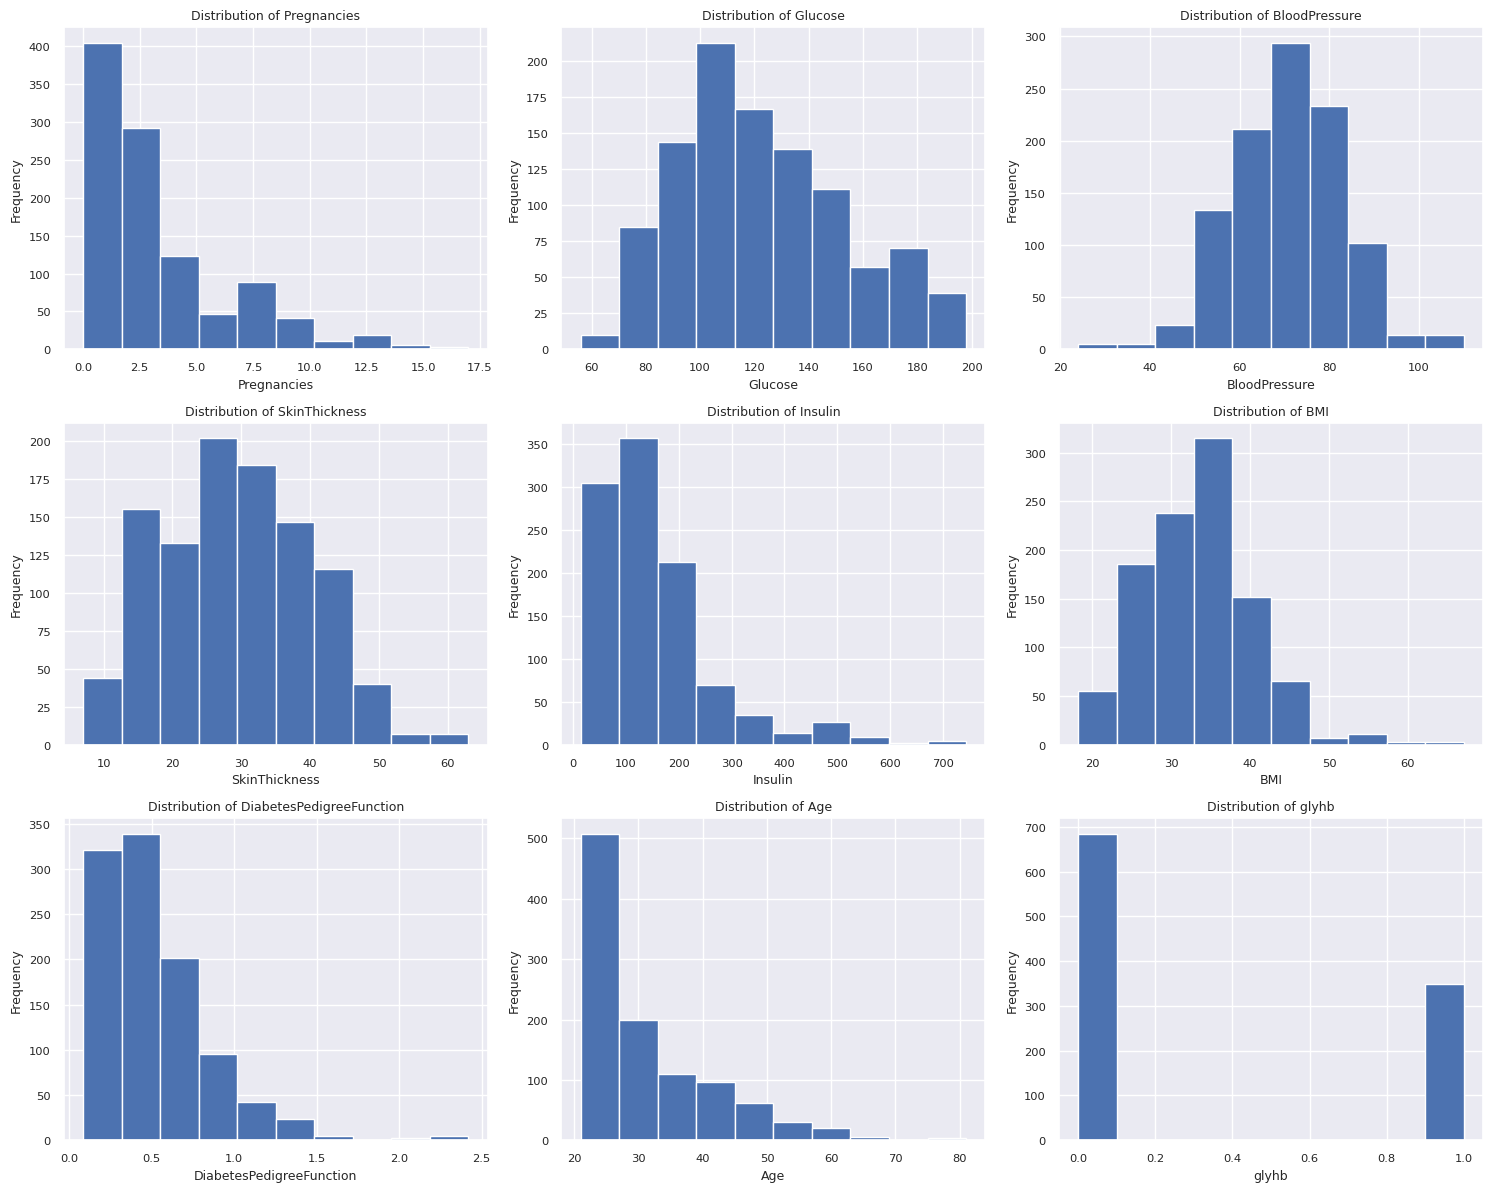

In [35]:
# Create a figure for all histograms
num_data_columns = len(diab_data3.columns)
num_cols_in_grid = 3 # Number of columns for the subplot grid
num_rows_in_grid = (num_data_columns + num_cols_in_grid - 1) // num_cols_in_grid # Calculate required rows

fig, axes = plt.subplots(num_rows_in_grid, num_cols_in_grid, figsize=(num_cols_in_grid * 5, num_rows_in_grid * 4))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, x_col in enumerate(diab_data3.columns):
    if i < len(axes): # Ensure we don't try to plot beyond available subplots
        diab_data3[x_col].plot.hist(ax=axes[i])
        axes[i].set_title(f'Distribution of {x_col}')
        axes[i].set_xlabel(x_col)
        axes[i].set_ylabel('Frequency')

# Hide any unused subplots if the number of data columns is not a perfect multiple of num_cols_in_grid
for j in range(num_data_columns, len(axes)):
    if j < len(axes):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
diab_data3.rename(columns={'Outcome': 'glyhb'}, inplace=True)

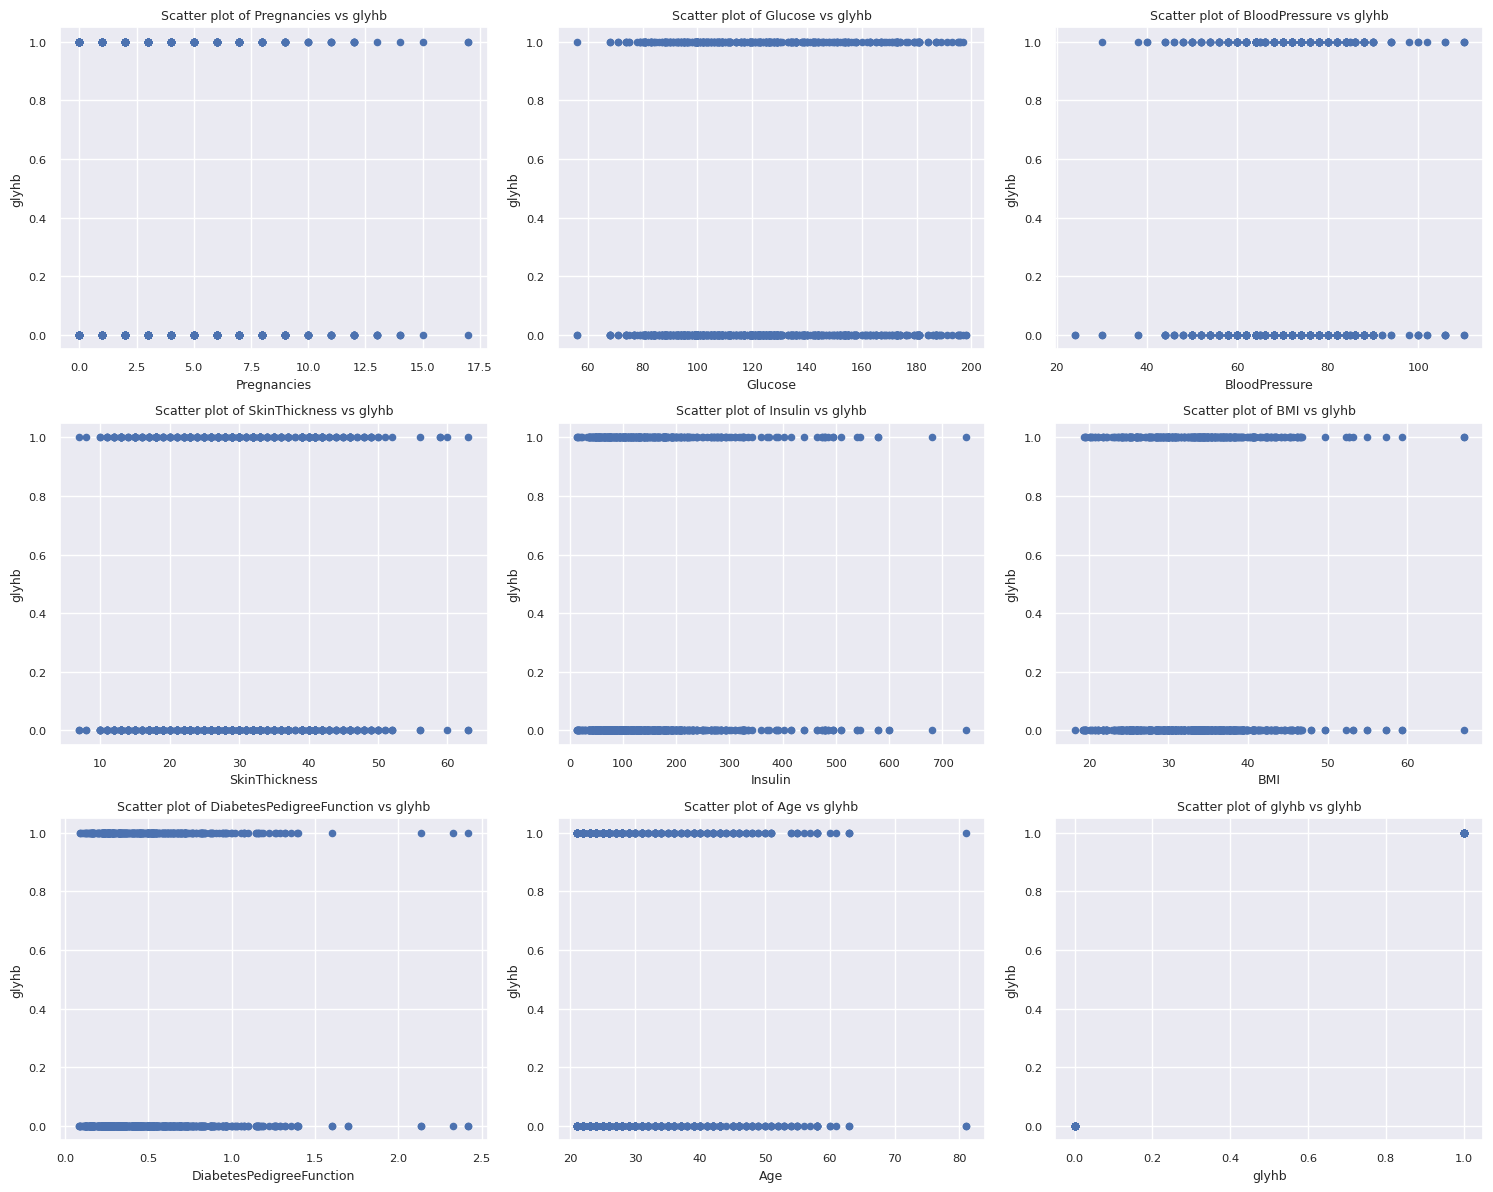

In [36]:
# Create a figure for all scatters
num_data_columns = len(diab_data3.columns)
num_cols_in_grid = 3 # Number of columns for the subplot grid

# Check if diab_data3 is empty or if 'glyhb' column exists
if diab_data3.empty:
    print("diab_data3 is empty after previous operations. Skipping scatter plot generation.")
elif 'glyhb' not in diab_data3.columns:
    print("The 'glyhb' column is not found in diab_data3. Skipping scatter plot generation.")
else:
    num_rows_in_grid = (num_data_columns + num_cols_in_grid - 1) // num_cols_in_grid # Calculate required rows

    fig, axes = plt.subplots(num_rows_in_grid, num_cols_in_grid, figsize=(num_cols_in_grid * 5, num_rows_in_grid * 4))
    axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

    for i, x_col in enumerate(diab_data3.columns):
        if i < len(axes): # Ensure we don't try to plot beyond available subplots
            # Call plot.scatter on the DataFrame itself, specifying x and y column names
            diab_data3.plot.scatter(x=x_col, y='glyhb', ax=axes[i])
            axes[i].set_title(f'Scatter plot of {x_col} vs glyhb')
            axes[i].set_xlabel(x_col)
            axes[i].set_ylabel('glyhb') # Correct ylabel for scatter plot

    # Hide any unused subplots if the number of data columns is not a perfect multiple of num_cols_in_grid
    for j in range(num_data_columns, len(axes)):
        if j < len(axes):
            fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

## 6.1 Comparing the two datasets

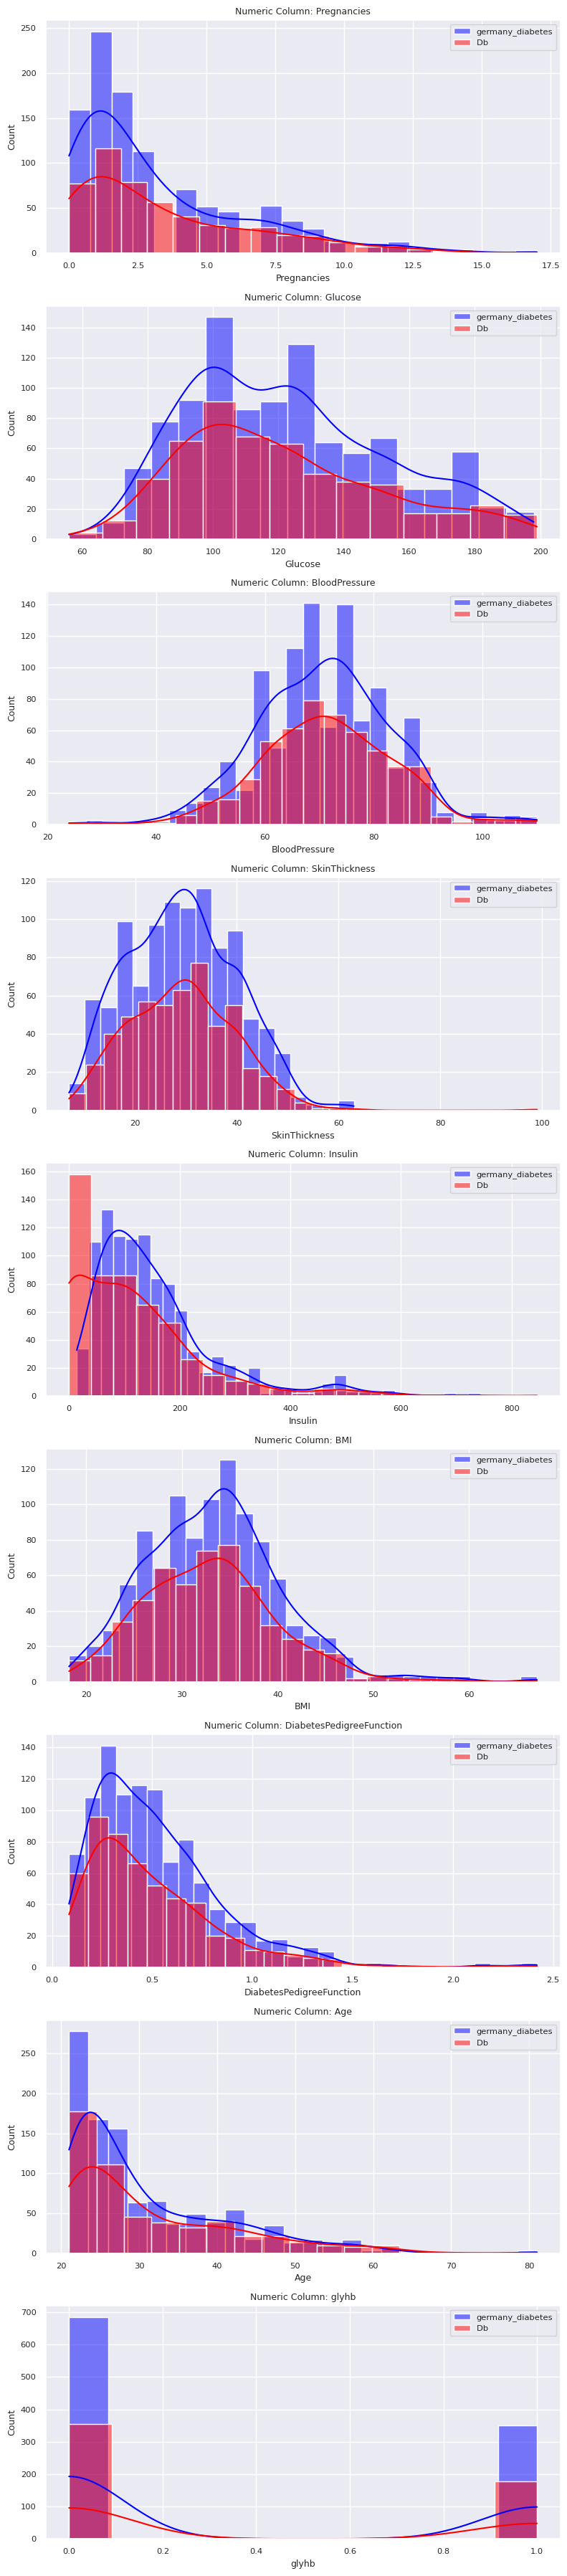

In [37]:
# Comparing germany and db datasets
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



df1 = pd.DataFrame(diab_data3)
df2 = pd.DataFrame(diab_data4)

# Ensure both datasets have the same columns
if set(df1.columns) != set(df2.columns):
    raise ValueError("Datasets must have the same columns for comparison.")

# Create a figure for subplots
num_cols = len(df1.columns)
fig, axes = plt.subplots(num_cols, 1, figsize=(8, 4 * num_cols))

if num_cols == 1:
    axes = [axes]  # Ensure axes is iterable

# Compare each column
for i, col in enumerate(df1.columns):
    if pd.api.types.is_numeric_dtype(df1[col]):
        # Numeric columns: plot side-by-side histograms
        sns.histplot(df1[col], color='blue', label='germany_diabetes', kde=True, ax=axes[i], alpha=0.5)
        sns.histplot(df2[col], color='red', label='Db ', kde=True, ax=axes[i], alpha=0.5)
        axes[i].set_title(f"Numeric Column: {col}")
        axes[i].legend()
    else:
        # Categorical columns: plot count comparison
        df_cat = pd.DataFrame({
            'Dataset': ['germany_diabetes'] * len(df1) + ['Db'] * len(df2),
            col: pd.concat([df1[col], df2[col]], ignore_index=True)
        })
        sns.countplot(data=df_cat, x=col, hue='Dataset', ax=axes[i])
        axes[i].set_title(f"Categorical Column: {col}")

plt.tight_layout()
plt.show()

## 6.2 Linear Regression Model: Predicting Glucose from `diab_data3`

In [38]:
# 1. Using linear regression for comparing Glucose's relations with other features in both datasets
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import numpy as np

# 1. Prepare the data
# Define the target variable (Glucose) and feature variables
y = diab_data3['Glucose']
X = diab_data3.drop('Glucose', axis=1)

# 2. Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Feature Scaling
# Standardize features to improve model performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrames with column names for clarity
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# 4. Train the Linear Regression Model
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)

# 5. Evaluate the Model
y_pred = linear_model.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

# Display coefficients (feature importance for linear regression)
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': linear_model.coef_
})
print("\nModel Coefficients:")
display(coefficients.sort_values(by='Coefficient', ascending=False))


Mean Squared Error (MSE): 564.32
R-squared (R2): 0.39

Model Coefficients:


,Feature,Coefficient
3,Insulin,15.544082
6,Age,6.492049
2,SkinThickness,1.877044
4,BMI,1.058002
5,DiabetesPedigreeFunction,0.701047
7,glyhb,0.659452
1,BloodPressure,0.366340
0,Pregnancies,-0.436469


## 6.3 Residual Analysis for `diab_data3`

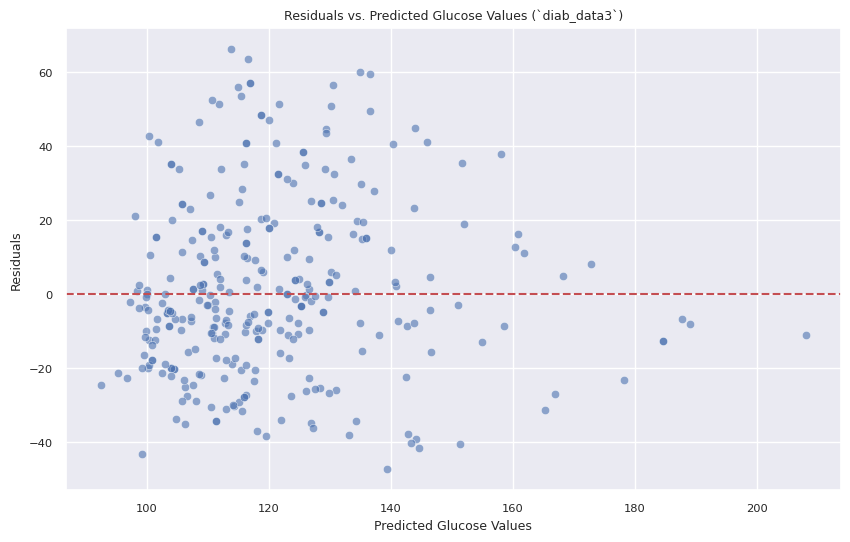

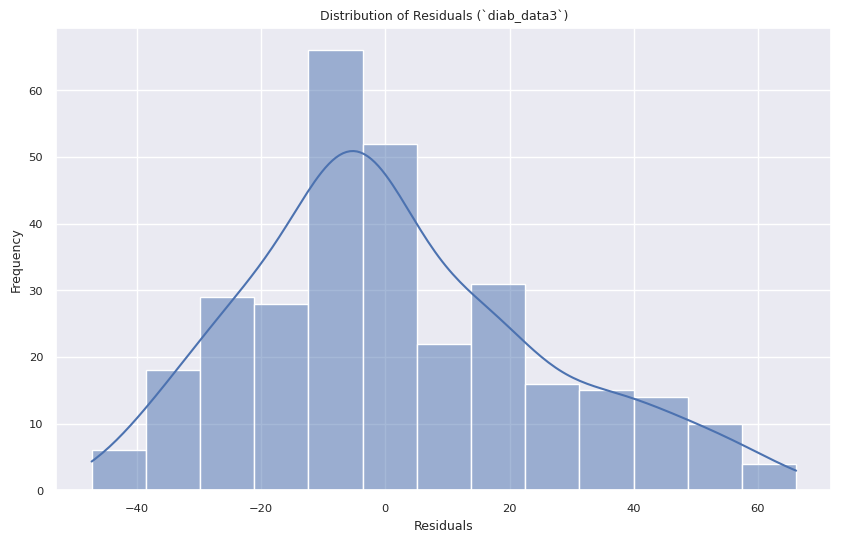

In [39]:


# --- Data Loading and Initial Preprocessing for diab_data3 ---
diab_data3 = pd.read_csv('/content/sample_data/germany_diabetes.csv')
diab_data3 = diab_data3.rename(columns={'Outcome': 'glyhb'})

# --- Re-define y_test and y_pred from the linear regression model for diab_data3 ---
y = diab_data3['Glucose']
X = diab_data3.drop('Glucose', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)

y_pred = linear_model.predict(X_test_scaled)

# Calculate residuals
residuals_diab3 = y_test - y_pred

# Plotting residuals vs. predicted values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals_diab3, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs. Predicted Glucose Values (`diab_data3`)')
plt.xlabel('Predicted Glucose Values')
plt.ylabel('Residuals')
plt.grid(True)
plt.show()

# Plotting a histogram of residuals
plt.figure(figsize=(10, 6))
sns.histplot(residuals_diab3, kde=True)
plt.title('Distribution of Residuals (`diab_data3`)')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

In [40]:
# Using linear regression for comparing Glucose's relations with other features in both datasets
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import numpy as np

# 1. Prepare the data
# Define the target variable (Glucose) and feature variables
y = diab_data4['Glucose']
X = diab_data4.drop('Glucose', axis=1)

# 2. Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Feature Scaling
# Standardize features to improve model performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrames with column names for clarity
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# 4. Train the Linear Regression Model
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)

# 5. Evaluate the Model
y_pred = linear_model.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

# Display coefficients (feature importance for linear regression)
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': linear_model.coef_
})
print("\nModel Coefficients:")
display(coefficients.sort_values(by='Coefficient', ascending=False))


Mean Squared Error (MSE): 580.56
R-squared (R2): 0.37

Model Coefficients:


,Feature,Coefficient
7,glyhb,11.496472
3,Insulin,11.119363
6,Age,6.252511
1,BloodPressure,3.562753
2,SkinThickness,0.692506
4,BMI,0.343210
5,DiabetesPedigreeFunction,-0.574862
0,Pregnancies,-3.864159


## 6.4 Residual Analysis for `diab_data4`

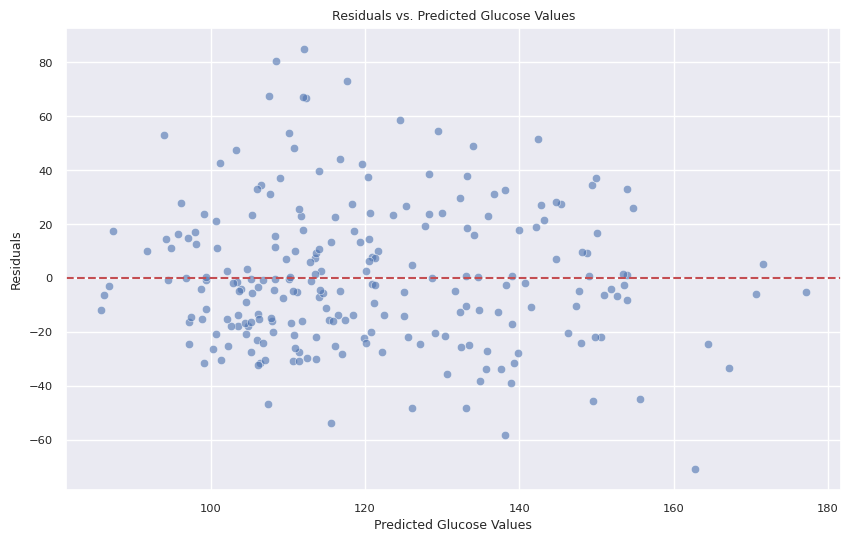

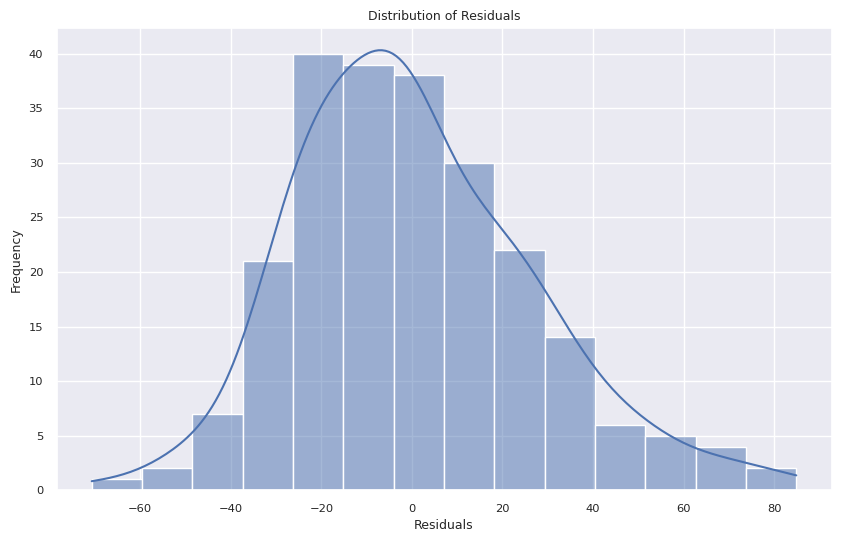

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate residuals
residuals = y_test - y_pred

# Plotting residuals vs. predicted values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs. Predicted Glucose Values')
plt.xlabel('Predicted Glucose Values')
plt.ylabel('Residuals')
plt.grid(True)
plt.show()

# Plotting a histogram of residuals
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True)
plt.title('Distribution of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

In [ ]:
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print(f"Sensitivity (True Positive Rate): {sensitivity:.2f}")
print(f"Specificity (True Negative Rate): {specificity:.2f}")

ValueError: Classification metrics can't handle a mix of multiclass and continuous targets

# 7 Discovering Biases in the dataset (germany_dataset)

In [25]:
# 1. Exploring Training and testing predictions
train_accuracy = accuracy_score(y3_train, model3.predict(X3_train))
test_accuracy = accuracy_score(y3_test, model3.predict(X3_test))

print(f"Training Accuracy: {train_accuracy}")
print(f"Testing Accuracy: {test_accuracy}")

Training Accuracy: 0.6690821256038647
Testing Accuracy: 0.6328502415458938


In [27]:
import scipy.stats as stats

# Kolmogorov-Smirnov test for feature distribution
stat, p_value = stats.ks_2samp(X3_train, X3_test)
print(f"KS Test Statistic: {stat}, P-value: {p_value}")

KS Test Statistic: [0.06038647 0.04227053 0.04347826 0.03985507 0.09782609 0.05676329
 0.02777778 0.03743961], P-value: [0.5696499  0.92171629 0.9051286  0.94971811 0.08072232 0.64777002
 0.99936904 0.97063522]
